# Stage 2: Land Use Analysis — Southern California (2003–2023)

**Project:** Southern California Warehouse Inventory - Caltrans 65A1345
**Institutions:** UC Davis (UCD) 
**Regulatory context:** Souther California Region
**Author:** Maria C. Valencia-Cardenas

---

## Overview

This notebook evaluates the interaction between spatiotemporal patterns of land use, freight logistics, and economic growth within the SCAG study area. It uses multi-temporal Landsat satellite imagery and supervised machine learning to classify and quantify annual land use change from 2003 to 2023.

**Research questions addressed:**

| # | Research Question |
|---|-------------------|
| RQ2.1 | How have regional land uses evolved spatially and temporally? |
| RQ2.2 | What are the differences in land-use transition intensity among the regions? |
| RQ2.3 | How do these patterns reflect logistics development trajectories? |

---

## Study Area

Seven counties in and around the South Coast AQMD:

| County | Abbreviation | Notes |
|--------|-------------|-------|
| Los Angeles | LA | Core freight region |
| San Bernardino | SB | Inland Empire logistics hub |
| Orange | OR | Coastal industrial mix |
| Riverside | RI | Rapidly expanding warehouse corridor |
| Ventura | VE | Northwest periphery |
| Imperial | IM | Border logistics (pending) |
| San Joaquin | SJ | Northern extension (pending) |

---

## Land Use Classification Schema

All classifications follow a harmonized 9-class schema derived from OSM tags and aligned with Corine Land Cover Level 2:

| Code | Class | Landsat Spectral Signature |
|------|-------|---------------------------|
| 0 | Residential | Moderate NDVI, high density |
| 1 | Commercial | Low NDVI, high NDBI, compact |
| 2 | Industrial | Very low NDVI, high SWIR1, high VIIRS |
| 3 | Agriculture | Seasonal NDVI, low NDBI |
| 4 | Nature/Vegetation | High NDVI, low NDBI |
| 5 | Water/Wetlands | High MNDWI, low NDVI |
| 6 | Institutional | Mixed; large footprints |
| 7 | Bare land/Other | Low NDVI, low NDBI |
| 8 | Transport | Linear patterns, high SWIR1 |

---

## Pipeline Summary

```
Step 1: Define study area (TIGER county boundaries via GEE)
Step 2: Build annual Landsat composites (2003–2023, summer + winter seasons)
Step 3: Extract spectral indices (NDVI, NDBI, MNDWI, SWIR1, LST, VIIRS)
Step 4: Prepare OSM training data (landuse polygons + road buffers)
Step 5: Supervised classification (Random Forest / SVM via GEE)
Step 6: Time series modeling (trend, break detection, clustering, Fourier)
```

---

## Accuracy Improvement Changelog

The following modifications were applied to improve classification accuracy
beyond the baseline OA=0.68 / Kappa=0.624 achieved for San Bernardino (2023).

| # | Improvement | Where applied | Expected gain |
|---|-------------|--------------|---------------|
| 1 | **Negative buffer (erosion)** on OSM training polygons | `clean_and_reclassify_osm_landuse` → `neg_buffer_m=90` | Removes boundary mixed-pixels; ~2–4 pp OA |
| 2 | **EVI** (Enhanced Vegetation Index) added as predictor | `add_indices` | Stronger Agr vs. Industrial contrast |
| 3 | **NDVI_var / EVI_var** (within-summer temporal variance) | Both composite builders | Key stable-roof vs. seasonal-crop discriminator |
| 4 | **SWIR1_homogeneity** (GLCM inverse difference moment) | `add_glcm` | Uniform warehouse rooftops → high homogeneity |
| 5 | **Modal (majority) filter** post-classification | `run_supervised_classification` | Removes salt-and-pepper noise |
| 6 | `minLeafPopulation=5` in Random Forest | Both RF classifiers | Reduces overfitting to noisy OSM labels |

**New default predictor bands:**
```
SR_B2, SR_B3, SR_B4, SR_B5, SR_B7,
SWIR1, NDVI, NDBI, MNDWI, EVI,
NDVI_std, SWIR1_std, LST_std, LST_C,
VIIRS_rad, VIIRS_log,
SWIR1_contrast, SWIR1_entropy, SWIR1_homogeneity,
NDVI_var, EVI_var
```

**Pending (awaiting SCAG data):**
- Integrate SCAG parcel ALU 2019/2021 to improve Commercial and Institutional classes



## 0. Environment Setup

### Requirements

Install dependencies before running (or use the provided `environment.yml`):

```bash
conda env create -f environment.yml
conda activate geo
```

**Key package versions (tested):**

| Package | Version | Purpose |
|---------|---------|---------|
| Python | 3.11.14 | Runtime |
| geopandas | 1.1.1 | Vector geospatial operations |
| shapely | 2.0.7 | Geometry processing |
| fiona | 1.10.1 | Spatial file I/O |
| pyproj | 3.7.1 | CRS transformations |
| numpy | 2.3.5 | Array operations |
| osmnx | latest | OpenStreetMap data access |
| overturemaps | latest | Overture Maps building data |
| ruptures | latest | Break detection (PELT/BinSeg) |
| scikit-learn | latest | KMeans clustering, scalers |
| tensorflow | latest | CNN classification |
| google-earth-engine | latest | Landsat imagery + classification |
| geemap | latest | GEE interactive mapping |

### Google Earth Engine Authentication

A GEE account is required. Run `ee.Authenticate()` once per machine.
See: https://developers.google.com/earth-engine/guides/auth

### CRS Convention

All local vector operations use **EPSG:3310** (California Albers, meters) for area
calculations. Outputs are reprojected to **EPSG:4326** (WGS84) for export and GEE.


In [1]:
# ── Standard library ──────────────────────────────────────────────────────────
import os
import re
import ast
import glob
import subprocess

# ── Scientific stack ───────────────────────────────────────────────────────────
import numpy as np                          # numpy 2.3.5
import pandas as pd                         # pandas (latest)
import matplotlib.pyplot as plt            # matplotlib (latest)
import statsmodels.api as sm
from scipy import stats
from io import BytesIO

# ── Geospatial stack ───────────────────────────────────────────────────────────
import shapely                              # shapely 2.0.7
from shapely.ops import unary_union
from shapely.validation import make_valid
import geopandas as gdp                    # geopandas 1.1.1
import fiona                               # fiona 1.10.1
import pyproj                              # pyproj 3.7.1

# ── OpenStreetMap ──────────────────────────────────────────────────────────────
import osmnx as ox
import requests

# ── Overture Maps ──────────────────────────────────────────────────────────────
import overturemaps as om

# ── Break detection ────────────────────────────────────────────────────────────
import ruptures as rpt

# ── Machine learning ───────────────────────────────────────────────────────────
# scikit-learn provides KMeans clustering and standardization utilities.
from sklearn.preprocessing import StandardScaler, MinMaxScaler
from sklearn.cluster import KMeans

# ── Deep learning (CNN classification) ────────────────────────────────────────
import tensorflow as tf
from sklearn.metrics import (confusion_matrix, cohen_kappa_score,
                              accuracy_score, classification_report)
from tensorflow.keras import layers, Model

# ── CRS constants ──────────────────────────────────────────────────────────────
CA_METERS = "EPSG:3310"   # California Albers — use for all area calculations
WGS84     = "EPSG:4326"   # WGS84 — use for export and GEE inputs

path = 'C:/Users/mariacvc/Box/Catalina Valencia/Project 4 - 2025NCST-Caltrans/Task2_LU_Analysis/Python/'   # Set this to your local data directory


c:\Users\mariacvc\AppData\Local\miniconda3\envs\geo\Lib\site-packages\requests\__init__.py:113: RequestsDependencyWarning: urllib3 (2.5.0) or chardet (6.0.0.post1)/charset_normalizer (3.4.4) doesn't match a supported version!
  warnings.warn(


In [2]:
# ── Google Earth Engine authentication & initialization ───────────────────────
# Only run ee.Authenticate() once per machine.
# On subsequent sessions, ee.Initialize() is sufficient.
import ee
import geemap

ee.Authenticate(auth_mode='notebook')   # Comment out after first run
ee.Initialize()
print("GEE initialized successfully.")


GEE initialized successfully.


## RQ2.1: Changes in Land Use Patterns Over Time and Space

---

### Step 1: Define Study Area and Time Frame

We use US Census TIGER/2018 county boundaries accessed via Google Earth Engine
to define per-county regions of interest (ROIs).

**Temporal scope:**

| Parameter | Value |
|-----------|-------|
| Start year | 2003 (Landsat 5 era) or 2012 (Landsat 8 era) |
| End year | 2023 |
| Frequency | Annual |
| Season | Summer composite (May–September) + winter contrast (Dec–Feb) |

**Why summer composites?**  
Summer maximizes solar elevation and minimizes cloud cover in Southern California,
producing the cleanest surface reflectance values. The NDVI contrast between
summer and winter provides a strong agricultural vs. urban discriminator.


In [3]:
# Define a function to get ROI by county and state FIPS
def get_roi(county_name, state_fips='06', dataset='TIGER/2018/Counties'):
    """
    Returns a region of interest (ROI) geometry for a specified county and state.

    Parameters
    ----------
    county_name : str
        Name of the county (e.g., 'Sacramento')
    state_fips : str, optional
        State FIPS code (default is '06' for California)
    dataset : str, optional
        FeatureCollection dataset to use (default: 'TIGER/2018/Counties')

    Returns
    -------
    ee.Geometry
        Geometry of the specified county
    """
    fc = ee.FeatureCollection(dataset)
    roi = fc.filter(ee.Filter.And(
        ee.Filter.eq('NAME', county_name),
        ee.Filter.eq('STATEFP', state_fips)
    )).geometry()
    return roi

---

### Step 2: Build Annual Landsat ImageCollections

This step assembles per-year Landsat Surface Reflectance collections covering
Landsat 5 (TM), 7 (ETM+), and 8/9 (OLI/TIRS) from the USGS Collection 2 Level-2
archive hosted on Google Earth Engine.

**Filter criteria:**

| Filter | Value | Rationale |
|--------|-------|-----------|
| Cloud cover | < 50% | Remove heavily obscured scenes |
| Sun elevation | > 40° | Avoid low-angle shadows |
| Image quality | > 6 (scale 1–9) | USGS quality score |
| Season | May–October | Peak summer window |

**Sensor coverage by year:**

| Period | Sensor | GEE Asset |
|--------|--------|-----------|
| 2003–2012 | Landsat 5 (TM) | `LANDSAT/LT05/C02/T1_L2` |
| 1999–2021 | Landsat 7 (ETM+) | `LANDSAT/LE07/C02/T1_L2` |
| 2013–present | Landsat 8/9 (OLI) | `LANDSAT/LC08/C02/T1_L2` |

> **Note on sensor harmonization:** Band designations differ between TM/ETM+ and OLI.
> All index calculations use sensor-aware band selection (see Step 3).


In [4]:
# Define function for ImageCollection
def get_landsat_collection(year, roi):
    """
    Returns a merged Landsat Surface Reflectance ImageCollection for a given year and ROI.
    Includes Landsat 5, 7, and 8/9 (OLI/TIRS) filtered for low clouds and good image quality.
    """
    start_date = ee.Date.fromYMD(year, 5, 1) # May
    end_date   = ee.Date.fromYMD(year, 10, 1) # Oct
    
    # Landsat 5 (TM)
    l5 = ee.ImageCollection('LANDSAT/LT05/C02/T1_L2') \
        .filterDate(start_date, end_date) \
        .filterBounds(roi) \
        .filterMetadata('CLOUD_COVER', 'less_than', 50)\
        .filter(ee.Filter.gt('SUN_ELEVATION', 40)) \
        .filter(ee.Filter.gt('IMAGE_QUALITY', 6)) \
        .map(lambda img: img.set('sensor', 'L5'))
    
    # Landsat 7 (ETM+)
    l7 = ee.ImageCollection('LANDSAT/LE07/C02/T1_L2') \
        .filterDate(start_date, end_date) \
        .filterBounds(roi) \
        .filterMetadata('CLOUD_COVER', 'less_than', 50)\
        .filter(ee.Filter.gt('SUN_ELEVATION', 40)) \
        .filter(ee.Filter.gt('IMAGE_QUALITY', 6)) \
        .map(lambda img: img.set('sensor', 'L7'))
    
    # Landsat 8/9 (OLI/TIRS)
    l8 = ee.ImageCollection('LANDSAT/LC08/C02/T1_L2') \
        .filterDate(start_date, end_date) \
        .filterBounds(roi) \
        .filterMetadata('CLOUD_COVER', 'less_than', 50)\
        .filter(ee.Filter.gt('SUN_ELEVATION', 40)) \
        .filter(ee.Filter.gt('IMAGE_QUALITY', 6)) \
        .map(lambda img: img.set('sensor', 'L8'))

    # Merge and return
    return l5.merge(l7).merge(l8)

# Get each year ImageCollection
def get_landsat_by_year(roi, start_year, end_year):
    """
    Builds a dictionary of annual Landsat ImageCollections for a specified ROI and year range.

    Parameters
    ----------
    roi : ee.Geometry
        Region of interest
    start_year : int
        Starting year (e.g., 2000)
    end_year : int
        Ending year (inclusive, e.g., 2024)

    Returns
    -------
    dict
        Dictionary with years as keys and Landsat ImageCollections as values
    """
    landsat_by_year = {}
    for year in range(start_year, end_year + 1):  # inclusive
        collection = get_landsat_collection(year, roi)
        landsat_by_year[year] = collection
        print("Landsat by year: ")
        print(f"Year {year}: {collection.size().getInfo()} images")
    return landsat_by_year

---

### Step 3: Extract Spectral Indices and Build Annual Composites

Each Landsat image is preprocessed with scale/offset correction, cloud masking,
and spectral index computation before being reduced to an annual median composite.

#### Preprocessing pipeline per image

```
apply_scale_offset()  →  qa_mask()  →  add_indices()  →  median composite
```

#### Spectral indices computed

| Index | Formula | Land use signal |
|-------|---------|-----------------|
| **NDVI** | (NIR − RED) / (NIR + RED) | Vegetation density |
| **NDBI** | (SWIR1 − NIR) / (SWIR1 + NIR) | Built-up surfaces |
| **MNDWI** | (GREEN − SWIR1) / (GREEN + SWIR1) | Water bodies |
| **SWIR1** | Band 6 (OLI) / Band 5 (TM) | Impervious surfaces, industrial roofs |
| **LST_C** | ST_B10 or ST_B6 (°C) | Industrial heat signature |
| **VIIRS_rad / log** | NOAA VIIRS DNB monthly (2012+) | Nighttime economic activity |

#### Texture features (GLCM, optional)

| Feature | Computation | Purpose |
|---------|-------------|---------|
| `SWIR1_contrast` | GLCM contrast (3×3) | Industrial roof texture |
| `SWIR1_entropy` | GLCM entropy (3×3) | Surface heterogeneity |
| `NDVI_std` | 90 m neighborhood std dev | Vegetation patchiness |
| `SWIR1_std` | 90 m neighborhood std dev | Built-up heterogeneity |
| `LST_std` | 90 m neighborhood std dev | Thermal variability |

#### Sensor-aware band picking

OLI (L8/9) uses different band numbers than TM/ETM+ (L5/7).
The `add_indices()` function detects `SPACECRAFT_ID` server-side to avoid
mismatched band assignments across sensors.

#### Seasonal stack option

`build_composites_by_year_seasonal()` creates a richer feature set by stacking
summer and winter medians with seasonal amplitude bands:

| Band suffix | Season |
|-------------|--------|
| `_su` | Jun–Sep median |
| `_wi` | Dec–Feb median |
| `NDVI_amp` | Summer NDVI − Winter NDVI |
| `NDBI_amp` | Summer NDBI − Winter NDBI |
| `SWIR1_amp` | Summer SWIR1 − Winter SWIR1 |

> **VIIRS artifact warning:** Adding VIIRS nightlights (`add_viirs=True`) significantly
> improves industrial zone detection but introduces a discontinuity at 2011–2012
> (onset of VIIRS). Use caution in long-term trend comparisons spanning this boundary.


In [5]:
# Helpers: scaling, masking, indices (Python API for Earth Engine)
# --- SCALE + OFFSET (USGS C2 L2 SR) ---
# Optical SR bands (SR_B1..SR_B7) use: reflectance = DN * 0.0000275 + (-0.2)

SCALE  = 0.0000275
OFFSET = -0.2
OPTICAL = ['SR_B1','SR_B2','SR_B3','SR_B4','SR_B5','SR_B6','SR_B7']  # L5/7 lack SR_B6

def present_optical_bands(img):
    bn = img.bandNames()
    def keep(b):
        b = ee.String(b)
        return ee.Algorithms.If(bn.contains(b), b, None)
    # Map over OPTICAL, keep those that actually exist on this image
    return ee.List(OPTICAL).map(keep).removeAll([None])

# scale only present optical bands
def apply_scale_offset(img):
    pb = present_optical_bands(img)  # ee.List of strings
    scaled = img.select(pb).multiply(SCALE).add(OFFSET)
    return img.addBands(scaled, overwrite=True)

# ---- QA mask (clouds + shadows + snow + dilated cloud; cirrus where present) ----
# USGS C2 L2 QA_PIXEL bits (check USGS doc if you want to adjust):
# 0: Fill; 1: Dilated Cloud; 2: Cirrus (L8/9); 3: Cloud; 4: Cloud Shadow; 5: Snow/Ice
def qa_mask(img):
    qa = img.select('QA_PIXEL')
    def keep_clear(bit): return qa.bitwiseAnd(1 << bit).eq(0)
    clear = (keep_clear(1)   # dilated cloud == 0
             .And(keep_clear(2))  # cirrus (L8/9) == 0
             .And(keep_clear(3))  # cloud == 0
             .And(keep_clear(4))  # cloud shadow == 0
             .And(keep_clear(5))) # snow == 0
    # Optionally also drop fill (bit 0):
    # clear = clear.And(keep_clear(0))
    return img.updateMask(clear)

# Define the Index Computation Function with Sensor Logic
# --- INDICES on SCALED BANDS ---
# ---- Sensor-aware band picking using metadata ----
# L8/9 have SENSOR_ID like 'OLI_TIRS' or 'OLI_TIRS_2'; L5/7 are 'TM'/'ETM'
def add_indices(img):
    sc = ee.String(img.get('SPACECRAFT_ID'))
    is_oli = ee.List(['LANDSAT_8','LANDSAT_9']).contains(sc)  # server-side boolean

    # NDVI
    ndvi = ee.Image(ee.Algorithms.If(
        is_oli,
        img.normalizedDifference(['SR_B5', 'SR_B4']),  # OLI: NIR, RED
        img.normalizedDifference(['SR_B4', 'SR_B3'])   # TM/ETM+: NIR, RED
    )).rename('NDVI')

    # NDBI
    ndbi = ee.Image(ee.Algorithms.If(
        is_oli,
        img.normalizedDifference(['SR_B6', 'SR_B5']),  # OLI: SWIR1, NIR
        img.normalizedDifference(['SR_B5', 'SR_B4'])   # TM/ETM+: SWIR1, NIR
    )).rename('NDBI')

    # MNDWI
    mndwi = ee.Image(ee.Algorithms.If(
        is_oli,
        img.normalizedDifference(['SR_B3', 'SR_B6']),  # OLI: GREEN, SWIR1
        img.normalizedDifference(['SR_B2', 'SR_B5'])   # TM/ETM+: GREEN, SWIR1
    )).rename('MNDWI')


    # EVI — Enhanced Vegetation Index
    # Less prone to saturation than NDVI in dense vegetation. Provides a
    # stronger signal contrast between irrigated agriculture (EVI > 0.4)
    # and industrial rooftops (EVI ≈ 0), reducing the Ind/Agr confusion.
    evi = ee.Image(ee.Algorithms.If(
        is_oli,
        img.expression(
            '2.5 * (NIR - RED) / (NIR + 6*RED - 7.5*BLUE + 1)',
            {'NIR': img.select('SR_B5'), 'RED': img.select('SR_B4'), 'BLUE': img.select('SR_B2')}
        ),
        img.expression(
            '2.5 * (NIR - RED) / (NIR + 6*RED - 7.5*BLUE + 1)',
            {'NIR': img.select('SR_B4'), 'RED': img.select('SR_B3'), 'BLUE': img.select('SR_B1')}
        )
    )).rename('EVI')

    return img.addBands([ndvi, ndbi, mndwi, evi])

# Map Over Each Year's Collection and Reduce with Median
# Dictionary to hold composite images per year
def prep_landsat(img):
    img = apply_scale_offset(img)
    img = qa_mask(img)
    img = add_indices(img)
    return img

# Add cross-sensor SWIR1 + textures (computed on the median composite)
def add_cross_sensor_swir1(med):
    # Choose SWIR1 that exists: SR_B6 (OLI) else SR_B5 (TM/ETM+)
    bn = med.bandNames()
    swir1 = ee.Image(ee.Algorithms.If(
        bn.contains('SR_B6'), med.select('SR_B6'), med.select('SR_B5')
    )).rename('SWIR1')
    return med.addBands(swir1, overwrite=True)

# Add morphology/texture for Industries (GLCM)
def add_glcm(med, size=3):
    # Quantize SWIR1 to 8-bit
    swir_q = med.select('SWIR1').unitScale(0.02, 0.6).multiply(255).toByte()
    glcm = swir_q.glcmTexture(size=size)
    # Pick the bands we want from EE's naming convention
    glcm_sel = glcm.select(['SWIR1_contrast', 'SWIR1_ent', 'SWIR1_idm'])
    # Rename to what YOUR pipeline expects
    # SWIR1_idm = Inverse Difference Moment (homogeneity).
    # Industrial warehouse rooftops are spectrally uniform → high homogeneity.
    # Vegetation and residential areas are heterogeneous → low homogeneity.
    glcm_sel = glcm_sel.rename(['SWIR1_contrast', 'SWIR1_entropy', 'SWIR1_homogeneity'])
    return med.addBands(glcm_sel)

# ---- Cross-sensor LST (Surface Temperature) ----
# Note: L2 ST_* bands are already surface temperature (Kelvin). Do NOT apply optical SCALE/OFFSET.
def add_cross_sensor_lst(med):
    bn = med.bandNames()
    lstK = ee.Image(ee.Algorithms.If(
        bn.contains('ST_B10'), med.select('ST_B10'),                             # Landsat 8/9
        ee.Algorithms.If(bn.contains('ST_B6'), med.select('ST_B6'), ee.Image(0)) # Landsat 5/7
    )).rename('LST_K')

    # Looser plausibility window; keep more pixels (Kelvin)
    lstK = lstK.updateMask(lstK.gt(260).And(lstK.lt(330)))

    # Fallback fill: if still masked somewhere, fill with a climatology-ish value
    # (use 295 K ≈ 21.85°C so the band exists everywhere for sampling)
    lstK_filled = lstK.unmask(295)

    lstC = lstK_filled.subtract(273.15).rename('LST_C')
    return med.addBands([lstK_filled.rename('LST_K'), lstC], overwrite=True)

# Add Nighttime Lights (VIIRS)
def add_viirs_nightlights(med, year):
    """Attach VIIRS mean summer nightlight radiance (2012+) to composite."""
    if year >= 2012:
        viirs = (
            ee.ImageCollection('NOAA/VIIRS/DNB/MONTHLY_V1/VCMCFG')
            .filterDate(f'{year}-06-01', f'{year}-09-30')
            .select('avg_rad')
            .mean()
            .clip(med.geometry())
        )
        # Add both raw and log-transformed versions safely
        viirs_rad = viirs.rename('VIIRS_rad')
        viirs_log = viirs_rad.log10().rename('VIIRS_log')
    else:
        # Fill missing years with zeros for both bands
        viirs_rad = ee.Image.constant(0).rename('VIIRS_rad').clip(med.geometry())
        viirs_log = ee.Image.constant(0).rename('VIIRS_log').clip(med.geometry())

    # Add both bands to the composite
    return med.addBands([viirs_rad, viirs_log], overwrite=True)

def add_textures(med, radius_m=90):
    # Neighborhood kernel in meters
    kernel = ee.Kernel.circle(radius_m, 'meters', normalize=False)
    ndvi_std  = med.select('NDVI').reduceNeighborhood(ee.Reducer.stdDev(), kernel).rename('NDVI_std')
    swir1_std = med.select('SWIR1').reduceNeighborhood(ee.Reducer.stdDev(), kernel).rename('SWIR1_std')
    # LST_std: compute where LST_C exists; fill to 0 so samples aren't dropped
    lst_std_raw = med.select('LST_C').reduceNeighborhood(ee.Reducer.stdDev(), kernel)
    lst_std     = lst_std_raw.rename('LST_std').unmask(0)
    return med.addBands([ndvi_std, swir1_std, lst_std], overwrite=True)




#### Seasonal composite builder

In [6]:
def rename_with_suffix(img, suffix, bands=None):
    bands = bands or img.bandNames()
    new_names = ee.List(bands).map(lambda b: ee.String(b).cat(suffix))
    return img.select(bands).rename(new_names)

def safe_median(col, roi, fallback=None):
    """Return median composite if collection has images, else fallback image."""
    n = col.size()
    return ee.Image(ee.Algorithms.If(n.gt(0), col.median().clip(roi), fallback))

def build_seasonal_stack_for_year(
    year, roi, landsat_by_year,
    use_glcm=True, add_viirs=True,
    summer_months=(6, 9),   # Jun–Sep
    # Winter spans Dec(prev year)–Feb(current year)
    winter_start_month=12, winter_end_month=2,
):
    y = ee.Number(year).toInt()

    # Base collections (already filtered by year in your dict)
    col_y = landsat_by_year[year]

    # Also need previous year's collection for December
    prev_year = int(year) - 1
    col_prev = landsat_by_year.get(prev_year, None)

    # Preprocess each image in the collections (masking, scaling, etc.)
    col_y = col_y.map(prep_landsat)
    if col_prev is not None:
        col_prev = col_prev.map(prep_landsat)

    # -------- Summer: within year y --------
    summer = col_y.filter(ee.Filter.calendarRange(summer_months[0], summer_months[1], "month"))
    summer_med = safe_median(summer, roi)

    # -------- Winter: Dec(y-1) + Jan-Feb(y) --------
    jan_feb = col_y.filter(ee.Filter.calendarRange(1, winter_end_month, "month"))
    if col_prev is not None:
        dec_prev = col_prev.filter(ee.Filter.calendarRange(winter_start_month, winter_start_month, "month"))
        winter = dec_prev.merge(jan_feb)
    else:
        # If you don't have prev year loaded, fallback to Jan-Feb only
        winter = jan_feb

    winter_med = safe_median(winter, roi, fallback=summer_med)

    # -------- Add your harmonization + indices/textures PER SEASON --------
    def enrich(med):
        med = add_cross_sensor_swir1(med)
        med = add_cross_sensor_lst(med)
        med = add_indices(med)       # if you have NDVI/NDBI/MNDWI as a function
        med = add_textures(med)      # your stdDev textures
        if use_glcm:
            med = add_glcm(med)      # your SWIR1_contrast/entropy
        return med

    summer_med = enrich(summer_med)
    winter_med = enrich(winter_med)

    # Optional: VIIRS is annual-ish; add once (same for whole stack)
    if add_viirs:
        viirs = add_viirs_nightlights(ee.Image(0).clip(roi), int(year))  # returns VIIRS bands
        # keep only VIIRS bands you want
        viirs = viirs.select(["VIIRS_rad", "VIIRS_log"])
    else:
        viirs = ee.Image([])

    # -------- Rename seasonal bands so they don't collide --------
    summer_med = rename_with_suffix(summer_med, "_su")
    winter_med = rename_with_suffix(winter_med, "_wi")

    # -------- Optional: add seasonal amplitude bands (VERY useful) --------
    ndvi_amp = summer_med.select("NDVI_su").subtract(winter_med.select("NDVI_wi")).rename("NDVI_amp")
    ndbi_amp = summer_med.select("NDBI_su").subtract(winter_med.select("NDBI_wi")).rename("NDBI_amp")
    swir1_amp = summer_med.select("SWIR1_su").subtract(winter_med.select("SWIR1_wi")).rename("SWIR1_amp")

    # Final stacked image
    stacked = ee.Image.cat([summer_med, winter_med, ndvi_amp, ndbi_amp, swir1_amp, viirs]).clip(roi)

    return stacked

#### Annual composite builder and regional pipeline

`build_composites_by_year()` loops over all years, applies the preprocessing
chain, and returns a `{year: ee.Image}` dictionary ready for classification.

`run_landsat_pipeline()` is the top-level convenience wrapper that calls
Steps 1–3 in sequence for a given county.


In [7]:
# Composites by year:
def build_composites_by_year(landsat_by_year, roi, use_glcm=False, add_viirs=True):
    """
    Builds annual median Landsat composites with harmonized bands and indices.

    Parameters
    ----------
    landsat_by_year : dict
        Dictionary of {year: ee.ImageCollection}
    roi : ee.Geometry
        Region of interest
    add_glcm : bool, optional
        Whether to include GLCM texture features (default: False)

    Returns
    -------
    dict
        Dictionary of {year: ee.Image} composites
    """
    composite_by_year = {}
    
    for year, collection in landsat_by_year.items():
        col = collection.map(prep_landsat)      
        med = col.median().clip(roi)           # scaled SR + indices in native proj 

        # Add consistent metrics
        med = add_cross_sensor_swir1(med)      # your existing SWIR1
        med = add_cross_sensor_lst(med)        # LST_K and LST_C
        med = add_textures(med)                # NDVI_std, SWIR1_std, LST_std             
        if use_glcm:
            med = add_glcm(med)                # SWIR1_contrast,SWIR1_entropy

        # NDVI & EVI temporal variance (within-year summer collection)
        # Even in the non-seasonal path, computing variance across available
        # summer images captures agricultural seasonality vs. stable rooftops.
        ndvi_col_y = col.filter(ee.Filter.calendarRange(6, 9, "month")).map(
            lambda img: add_indices(img).select("NDVI")
        )
        evi_col_y = col.filter(ee.Filter.calendarRange(6, 9, "month")).map(
            lambda img: add_indices(img).select("EVI")
        )
        ndvi_var_y = ee.Image(ee.Algorithms.If(
            ndvi_col_y.size().gt(1),
            ndvi_col_y.reduce(ee.Reducer.variance()).rename("NDVI_var"),
            ee.Image.constant(0).rename("NDVI_var")
        ))
        evi_var_y = ee.Image(ee.Algorithms.If(
            evi_col_y.size().gt(1),
            evi_col_y.reduce(ee.Reducer.variance()).rename("EVI_var"),
            ee.Image.constant(0).rename("EVI_var")
        ))
        med = med.addBands([ndvi_var_y, evi_var_y], overwrite=True)

        
        if add_viirs:
            med = add_viirs_nightlights(med, year) # This improve significantly the industrial zone detection. However, generates an artifact afecting contiuity 2011-12

        composite_by_year[year] = med
        print(f"Composite for {year} ready.")
    
    return composite_by_year

# Composite by year with seasons
def build_composites_by_year_seasonal(landsat_by_year, roi, use_glcm=False, add_viirs=True):
    composite_by_year = {}
    years = sorted(list(landsat_by_year.keys()))

    for year in years:
        # Skip years outside your desired range if needed
        composite_by_year[year] = build_seasonal_stack_for_year(
            year=year,
            roi=roi,
            landsat_by_year=landsat_by_year,
            use_glcm=use_glcm,
            add_viirs=add_viirs
        )
        print(f"Seasonal composite for {year} ready.")

    return composite_by_year

# Regional pipeline
def run_landsat_pipeline(county_name, state_fips, start_year, end_year, use_glcm=True):
    """
    Full Landsat SR → Indices → Composite pipeline for a given county and time range.
    """
    roi = get_roi(county_name, state_fips)                                        # Step 1
    landsat_by_year = get_landsat_by_year(roi, start_year, end_year)              # Step 2
    composite_by_year = build_composites_by_year(landsat_by_year, roi, use_glcm)  # Step 3
    return roi, landsat_by_year, composite_by_year

---

### Step 4: Prepare OSM Training Data

Training polygons are derived from OpenStreetMap (OSM) using a three-stage process:
(1) download raw landuse polygons, (2) reclassify to the 9-class schema, and
(3) add road polygons as the Transport class.

OSM tags are mapped to [Corine Land Cover Level 2](https://land.copernicus.eu/pan-european/corine-land-cover)
categories, then simplified to the 9-class schema used throughout this project.

#### 4.1 Download OSM Land Use Polygons

Tags queried: `landuse`, `natural` (water, wetland), `waterway`.


In [8]:

def get_osm_landuse(place_name, download_year=None, landuse_tags=None):
    """
    Downloads OSM land use polygons for a given place.

    Parameters
    ----------
    place_name : str
        Place name (e.g., 'Sacramento, California, USA')
    download_year : int, optional
        Year of download (added as 'source_year' column)
    landuse_tags : dict, optional
        OSM tags to filter by, default is {'landuse': True}

    Returns
    -------
    gpd.GeoDataFrame
        GeoDataFrame of OSM land use polygons
    """
    # Default parameters
    if landuse_tags is None:
        landuse_tags = {
            'landuse': True,
            'natural': ['water', 'wetland'],
            'waterway': True
        }
    if download_year is None:
        from datetime import datetime
        download_year = datetime.now().year

    # OSMnx unified function for geometries (2.x) or fallback for 1.x
    if hasattr(ox, "features_from_place"):
        gdf = ox.features_from_place(place_name, tags=landuse_tags)
    else:
        gdf = ox.geometries_from_place(place_name, tags=landuse_tags)

    # Add source year
    gdf["source_year"] = download_year

    # Keep only polygons
    gdf = gdf[gdf.geometry.type.isin(["Polygon", "MultiPolygon"])]

    # Reset CRS to WGS84 for consistency
    gdf = gdf.to_crs(epsg=4326)

    print(f"✅ Downloaded {len(gdf)} land-use features from OSM for {place_name}")
    print("Unique landuse types:", gdf["landuse"].value_counts().to_dict())

    return gdf



#### 4.2 Clean and Reclassify OSM Land Use Data

Raw OSM tags are harmonized to the 9-class schema. The reclassification map below
shows the full tag-to-class assignment:

| OSM Tag(s) | → Class | Code |
|-----------|---------|------|
| residential, private, garages | Residential | 0 |
| commercial, retail | Commercial | 1 |
| industrial, quarry, landfill, construction, brownfield | Industrial | 2 |
| farmland, orchard, vineyard, farmyard, … | Agriculture | 3 |
| park, garden, grass, meadow, wood, forest, … | Nature_Vegetation | 4 |
| water, wetland, salt_pond, basin | Water/Wetlands | 5 |
| cemetery, school, military, hospital, church, … | Institutional | 6 |
| common, brownfield, construction, quarry | Bare_land/other | 7 |
| railway, highway, port, parking | Transport | 8 |

> Tags that do not match any class are dropped to avoid label noise.


In [9]:
def clean_and_reclassify_osm_landuse(gdf, simplify_tolerance=10, neg_buffer_m=90):
    """
    Cleans and reclassifies OSM land use polygons into standardized classes.

    Parameters
    ----------
    gdf : gpd.GeoDataFrame
        Raw OSM land use GeoDataFrame.
    output_path : str, optional
        Path to save the cleaned shapefile (e.g., 'data/osm_lulc_training.shp').
        If None, the file will not be saved.
    simplify_tolerance : float, optional
        Geometry simplification tolerance (meters). Default = 10.
    neg_buffer_m : float, optional
        Inward (negative) buffer in meters applied to each polygon before
        sampling. Removes boundary pixels that straddle two land-use classes
        and introduce mixed spectral signals. Default 90 m (≈ 3 Landsat px).
        Set to 0 to disable. Polygons that collapse to empty are dropped.

    Returns
    -------
    gpd.GeoDataFrame
        Cleaned and reclassified GeoDataFrame with columns:
        ['geometry', 'landuse', 'landuse_group', 'landuse_code']
    """

    # --- 1. Ensure required columns exist ---
    for col in ['landuse', 'amenity', 'leisure', 'natural']:
        if col not in gdf.columns:
            gdf[col] = None

    # --- 2. Fill missing 'landuse' from other attributes ---
    gdf['landuse'] = gdf['landuse'].fillna(gdf['amenity'])
    gdf['landuse'] = gdf['landuse'].fillna(gdf['leisure'])
    gdf['landuse'] = gdf['landuse'].fillna(gdf['natural'])

    # --- 3. Drop rows with no landuse ---
    gdf = gdf[gdf['landuse'].notnull()].copy()

    # --- 4. Define reclassification map ---
    reclass_map = {
        # 0-Residential
        'residential': 'Residential', 'private': 'Residential', 'garages': 'Residential',
        # 1-Commercial
        'commercial': 'Commercial', 'retail': 'Commercial',
        # 2-Industrial
        'industrial': 'Industrial', 'quarry': 'Industrial', 'landfill': 'Industrial', 'construction': 'Industrial', 'brownfield': 'Industrial',
        # 3-Agriculture
        'farmland': 'Agriculture', 'orchard': 'Agriculture', 'vineyard': 'Agriculture', 'farmyard': 'Agriculture', 'farm': 'Agriculture',
        'aquaculture': 'Agriculture', 'greenhouse_horticulture': 'Agriculture', 'plant_nursery': 'Agriculture', 'allotments': 'Agriculture',
        'animal_keeping': 'Agriculture',
        # 4-Nature/Vegetation
        'park' : 'Nature_Vegetation', 'garden': 'Nature_Vegetation', 'playground': 'Nature_Vegetation', 'flowerbed': 'Nature_Vegetation',
        'village_green': 'Nature_Vegetation', 'greenery': 'Nature_Vegetation', 'picnic_table': 'Nature_Vegetation',
        'greenfield': 'Nature_Vegetation', 'grass': 'Nature_Vegetation', 'grassland': 'Nature_Vegetation',
        'meadow': 'Nature_Vegetation', 'scrub': 'Nature_Vegetation', 'heath': 'Nature_Vegetation', 'wood': 'Nature_Vegetation', 'forest': 'Nature_Vegetation',
        'fell': 'Nature_Vegetation', 'tree_row': 'Nature_Vegetation', 'bare_rock': 'Nature_Vegetation', 'sand': 'Nature_Vegetation', 'rock': 'Nature_Vegetation',
        'scree': 'Nature_Vegetation', 'cliff': 'Nature_Vegetation', 'stone': 'Nature_Vegetation', 'logging': 'Nature_Vegetation',
        # 5-Water/Wetlands
        'water': 'Water/Wetlands', 'wetland': 'Water/Wetlands', 'salt_pond': 'Water/Wetlands', 'basin': 'Water/Wetlands', 
        # 6-Institutional 
        'cemetery': 'Institutional', 'grave_yard': 'Institutional', 'school': 'Institutional', 'place_of_worship': 'Institutional', 'social_facility': 'Institutional',
        'toilets': 'Institutional', 'military': 'Institutional', 'education': 'Institutional', 'fairground': 'Institutional', 'institutional': 'Institutional',
        'recreation_ground': 'Institutional', 'religious': 'Institutional', 'sports_centre': 'Institutional', 'stadium': 'Institutional', 'College': 'Institutional',  
        'school': 'Institutional', 'university': 'Institutional', 'hospital': 'Institutional', 'clinic': 'Institutional', 'library': 'Institutional', 'museum': 'Institutional', 'townhall': 'Institutional',
        'government': 'Institutional', 'fire_station': 'Institutional', 'police_station': 'Institutional', 'kindergarten': 'Institutional',
        'church': 'Institutional', 'temple': 'Institutional', 'mosque': 'Institutional', 'chapel': 'Institutional', 'cathedral': 'Institutional', 'kingdom_hall': 'Institutional',
        'monastery': 'Institutional', 'presbytery': 'Institutional', 'shrine': 'Institutional', 'synagogue': 'Institutional', 
        # 7-Bare land / other
        'common': 'Bare_land/other', 'brownfield': 'Bare_land/other', 'construction': 'Bare_land/other', 
        'landfill': 'Bare_land/other', 'quarry': 'Bare_land/other', 
        # 8-Transport
        'railway': 'Transport', 'track': 'Transport', 'highway': 'Transport', 'port': 'Transport', 'parking': 'Transport'
    }

    # --- 5. Apply reclassification ---
    gdf['landuse_group'] = gdf['landuse'].map(reclass_map)
    
    # drop ambiguous "other" and nulls (if any landuse didn't match the map)
    gdf = gdf[(gdf["landuse_group"] != "other") & (gdf["landuse_group"].notnull())].copy()



    # --- 5b. Negative buffer (erosion) — remove boundary edge pixels ---
    # Polygon edges in OSM often straddle two land-use classes, so Landsat
    # pixels sampled near boundaries carry mixed spectral signals. Eroding
    # each polygon by neg_buffer_m guarantees sampled pixels are well inside
    # their labelled class. Polygons that collapse to empty or become smaller
    # than one Landsat pixel (900 m²) are discarded.
    if neg_buffer_m > 0:
        _crs_orig = gdf.crs
        gdf_m = gdf.to_crs(CA_METERS)
        gdf_m = gdf_m[gdf_m.geometry.notnull() & ~gdf_m.geometry.is_empty].copy()
        gdf_m["geometry"] = gdf_m.geometry.buffer(-neg_buffer_m)
        gdf_m = gdf_m[gdf_m.geometry.notnull() & ~gdf_m.geometry.is_empty].copy()
        gdf_m = gdf_m[gdf_m.geometry.is_valid].copy()
        gdf_m["_area_m2"] = gdf_m.geometry.area
        gdf_m = gdf_m[gdf_m["_area_m2"] >= 900].drop(columns=["_area_m2"])
        gdf = gdf_m.to_crs(_crs_orig)
        print(f"  → After {neg_buffer_m} m erosion: {len(gdf)} polygons remain")

    # --- 6. Assign numeric codes ---
    code_map = {
        'Residential': 0, 'Commercial': 1, 'Industrial': 2, 'Agriculture': 3,
        'Nature_Vegetation': 4, 'Water/Wetlands': 5, 'Institutional': 6,
        'Bare_land/other': 7, 'Transport': 8
    }
    gdf['landuse_code'] = gdf['landuse_group'].map(code_map)

    # --- 7. Print summary ---
    print("\n✅ Cleaned and reclassified OSM polygons")
    print(f"Total features: {len(gdf)}")
    print("Land use classes:\n", gdf['landuse_group'].value_counts())

    return gdf



#### 4.3 Build Transport Polygons from OSM Roads

OSM roads (polylines) are downloaded, filtered to drivable types, and buffered
to polygons (default 5 m half-width). This creates the Transport training class,
which OSM landuse polygons do not reliably cover.

**Road types included:** motorway, trunk, primary, secondary, tertiary,
residential, unclassified, service.


In [10]:
# A projected CRS for CA (meters)
CA_METERS = "EPSG:3310"   # California Albers
WGS84     = "EPSG:4326"

def get_osm_roads(place_name, buffer_m=5,
                  keep=('motorway','trunk','primary','secondary','tertiary',
                        'residential','unclassified','service')):
    """
    Downloads OSM drivable roads for `place_name`, buffers them to polygons, 
    and returns a cleaned 'Transportation' layer suitable for LULC training.
    """
    # 1. Download drive network
    G = ox.graph_from_place(place_name, network_type="drive")
    edges = ox.graph_to_gdfs(G, nodes=False, edges=True)

    # 2. Normalize and filter highway type
    if 'highway' in edges.columns:
        edges['hwy'] = edges['highway'].apply(lambda v: v[0] if isinstance(v, list) else v)
        edges = edges[edges['hwy'].isin(keep)]

    # 3. Project to meters for buffering
    edges_m = edges.to_crs(CA_METERS)

    # 4. Buffer with rounded ends (cap_style=1), no dissolve overlaps
    buffered = edges_m.geometry.buffer(buffer_m, cap_style=1, join_style=2)
    #merged = unary_union(buffered)  # dissolve touching buffers

    # 5. Convert back to GeoDataFrame and reproject to WGS84
    roads = gdp.GeoDataFrame({'geometry': buffered}, crs=CA_METERS)
    roads = roads.explode(index_parts=False, ignore_index=True)

    # 6. Clean geometry (remove empties or invalid shapes)
    roads = roads[roads.geometry.notnull() & ~roads.geometry.is_empty].copy()
    roads = roads.to_crs(WGS84)
    roads = roads[roads.geometry.is_valid].copy()
    
    # Keep only polygons
    roads = roads[roads.geometry.type.isin(["Polygon", "MultiPolygon"])]

    # 7. Add classification fields
    roads['landuse_group'] = 'Transport'
    roads['landuse_code'] = 8

    print(f"✅ Downloaded and buffered {len(roads)} cleaned road polygons for {place_name}")
    return roads[['geometry','landuse_group','landuse_code']]


#### 4.4 Merge OSM Layers and Resolve Spatial Overlaps

OSM landuse and road polygons frequently overlap. The following rules are
applied in priority order to produce a consistent, non-overlapping training dataset:

| Rule | Overlap Pair | Action |
|------|-------------|--------|
| 1 | Water/Wetlands vs. any class | Keep Water; cut others |
| 2 | Agriculture vs. Nature_Vegetation | Cut overlap from larger polygon |
| 3 | Bare_land/other vs. any class | Remove Bare_land/other where it overlaps |
| 4 | Residential vs. Nature_Vegetation | Cut from Residential |
| 5 | Industrial vs. Nature_Vegetation | Cut from both |
| 6 | Transport vs. any class | Keep Transport; cut others |
| 7 | Industrial vs. Commercial | Remove overlapping Commercial |

**Geometry helpers used:**

| Function | Purpose |
|----------|---------|
| `_make_valid()` | Repair invalid geometries using `shapely.make_valid` |
| `_explode()` | Decompose MultiPolygons into single parts |
| `_drop_small_slivers()` | Remove fragments < 50 m² after cutting |
| `_dissolve_union()` | Chunked union of a class to use as cutter mask |


In [11]:
def _make_valid(gdf):
    gdf = gdf[gdf.geometry.notnull() & ~gdf.geometry.is_empty].copy()
    # make_valid can return GeometryCollection; keep polygonal pieces only
    fixed = []
    for geom in gdf.geometry.values:
        try:
            g = make_valid(geom)
        except Exception:
            g = geom.buffer(0)  # fallback

        # keep only polygonal parts
        if g.geom_type == "Polygon" or g.geom_type == "MultiPolygon":
            fixed.append(g)
        elif g.geom_type == "GeometryCollection":
            polys = [x for x in g.geoms if x.geom_type in ("Polygon","MultiPolygon")]
            fixed.append(shapely.union_all(polys) if polys else shapely.GeometryCollection())
        else:
            fixed.append(shapely.GeometryCollection())
    gdf.geometry = fixed
    gdf = gdf[gdf.geometry.notnull() & ~gdf.geometry.is_empty].copy()
    gdf = gdf[gdf.is_valid]
    return gdf

def _make_valid_geom(geom):
    """Return a polygonal (Multi)Polygon or EMPTY GeometryCollection."""
    if geom is None or geom.is_empty:
        return shapely.GeometryCollection()

    try:
        g = make_valid(geom)
    except Exception:
        g = geom.buffer(0)

    if g.geom_type in ("Polygon", "MultiPolygon"):
        return g

    if g.geom_type == "GeometryCollection":
        polys = [x for x in g.geoms if x.geom_type in ("Polygon", "MultiPolygon")]
        return shapely.union_all(polys) if polys else shapely.GeometryCollection()

    return shapely.GeometryCollection()

def _explode(gdf):
    # works across geopandas versions
    try:
        return gdf.explode(ignore_index=True)
    except TypeError:
        return gdf.explode(index_parts=False).reset_index(drop=True)
    
def _drop_small_slivers(gdf, min_area_m2=50, area_crs=CA_METERS):
    g = gdf.to_crs(area_crs).copy()
    g["_a"] = g.geometry.area
    g = g[g["_a"] >= min_area_m2].drop(columns=["_a"])
    return g.to_crs(gdf.crs)


def _dissolve_union(gdf, simplify_tol=None, chunk=5000):
    if gdf.empty:
        return None

    gdf2 = gdf[gdf.geometry.notnull() & ~gdf.geometry.is_empty].copy()

    # ✅ FIX INVALID GEOMS (apply to each geometry)
    def _fix(geom):
        try:
            g = make_valid(geom)
        except Exception:
            g = geom.buffer(0)

        # Keep only polygonal pieces (avoid GeometryCollections)
        if g.geom_type in ("Polygon", "MultiPolygon"):
            return g
        if g.geom_type == "GeometryCollection":
            polys = [x for x in g.geoms if x.geom_type in ("Polygon", "MultiPolygon")]
            return shapely.union_all(polys) if polys else shapely.GeometryCollection()
        return shapely.GeometryCollection()

    gdf2["geometry"] = gdf2.geometry.apply(_fix)
    gdf2 = gdf2[gdf2.geometry.notnull() & ~gdf2.geometry.is_empty].copy()
    gdf2 = gdf2[gdf2.is_valid]

    if gdf2.empty:
        return None

    # Optional simplify (in projected CRS units, e.g., meters in EPSG:3310)
    if simplify_tol is not None and simplify_tol > 0:
        gdf2["geometry"] = gdf2.geometry.simplify(simplify_tol, preserve_topology=True)
        gdf2 = gdf2[gdf2.is_valid & ~gdf2.geometry.is_empty]

    geoms = list(gdf2.geometry.values)
    if not geoms:
        return None

    # ✅ Chunked union
    parts = []
    for i in range(0, len(geoms), chunk):
        parts.append(unary_union(geoms[i:i+chunk]))

    return unary_union(parts)


def cut_targets_by_cutters(
    gdf,
    cutters_class,
    targets_class,
    group_col="landuse_group",
    area_crs=CA_METERS,
    min_area_m2=50,
):
    """
    Keep cutters intact.
    Subtract (difference) cutters union from all target geometries.
    """
    gdf = gdf.copy()

    cutters = gdf[gdf[group_col].eq(cutters_class)]
    targets = gdf[gdf[group_col].eq(targets_class)]

    if cutters.empty or targets.empty:
        return gdf

    cutters_u = _dissolve_union(cutters.to_crs(area_crs))
    if cutters_u is None or cutters_u.is_empty:
        return gdf
    
    # ✅ cutters_u is a shapely geometry, validate as geometry (not gdf)
    cutters_u = _make_valid_geom(cutters_u)
    if cutters_u.is_empty:
        return gdf
    
    # ✅ targets is a GeoDataFrame
    targets = _make_valid(targets)
    
    # work in meters for stable topology
    targets_m = targets.to_crs(area_crs).copy()
    targets_m["geometry"] = targets_m.geometry.apply(lambda geom: geom.difference(cutters_u))

    # clean up
    targets_m = _explode(targets_m)
    targets_m = _drop_small_slivers(targets_m, min_area_m2=min_area_m2, area_crs=area_crs)

    # put back and return
    keep_other = gdf[~gdf[group_col].eq(targets_class)]
    out = pd.concat([keep_other, targets_m.to_crs(gdf.crs)], ignore_index=True)
    out = gdp.GeoDataFrame(out, crs=gdf.crs)
    return out


def cut_both_classes(
    gdf,
    class_a,
    class_b,
    group_col="landuse_group",
    area_crs=CA_METERS,
    min_area_m2=50,
):
    """
    Remove overlap from BOTH classes:
      A := A - (A∩B)
      B := B - (A∩B)
    Implemented by subtracting each other's union.
    """
    gdf2 = cut_targets_by_cutters(
        gdf, cutters_class=class_b, targets_class=class_a,
        group_col=group_col, area_crs=area_crs, min_area_m2=min_area_m2
    )
    gdf3 = cut_targets_by_cutters(
        gdf2, cutters_class=class_a, targets_class=class_b,
        group_col=group_col, area_crs=area_crs, min_area_m2=min_area_m2
    )
    return gdf3


def drop_overlap_area_from_class(
    gdf,
    drop_class,
    against_class,
    group_col="landuse_group",
    area_crs=CA_METERS,
    min_area_m2=50,
):
    """
    Equivalent to: drop_class := drop_class - (drop_class ∩ against_class),
    i.e., 'remove the drop_class where it overlaps against_class'.
    """
    return cut_targets_by_cutters(
        gdf,
        cutters_class=against_class,
        targets_class=drop_class,
        group_col=group_col,
        area_crs=area_crs,
        min_area_m2=min_area_m2,
    )

def cut_agri_vs_nature_from_bigger_polygon(
    gdf,
    agri_class="Agriculture",
    nature_class="Nature_Vegetation",
    group_col="landuse_group",
    area_crs=CA_METERS,
    min_area_m2=50,
):
    """
    For each intersecting pair (agri poly, nature poly),
    subtract the intersection from whichever polygon has larger AREA.
    """
    gdf = gdf.copy()

    A = gdf[gdf[group_col].eq(agri_class)].copy()
    B = gdf[gdf[group_col].eq(nature_class)].copy()
    if A.empty or B.empty:
        return gdf

    # project
    A_m = A.to_crs(area_crs).copy()
    B_m = B.to_crs(area_crs).copy()
    A_m["__area"] = A_m.geometry.area
    B_m["__area"] = B_m.geometry.area

    # keep original indices for updating
    A_m["__idx"] = A_m.index
    B_m["__idx"] = B_m.index

    # overlay intersection (keeps index references)
    inter = gdp.overlay(
        A_m[["__idx", "__area", "geometry"]],
        B_m[["__idx", "__area", "geometry"]],
        how="intersection",
        keep_geom_type=False,
    )
    if inter.empty:
        return gdf

    # inter columns become __idx_1, __area_1, __idx_2, __area_2, geometry
    # Decide which side is bigger; subtract intersection from that polygon
    inter["cut_A"] = inter["__area_1"] >= inter["__area_2"]  # True => cut Agriculture polygon
    inter["cut_B"] = ~inter["cut_A"]                          # else cut Nature polygon

    # Group intersection pieces by polygon id and union them, then difference
    cutA = inter[inter["cut_A"]].groupby("__idx_1")["geometry"].apply(lambda s: unary_union(s.values)).to_dict()
    cutB = inter[inter["cut_B"]].groupby("__idx_2")["geometry"].apply(lambda s: unary_union(s.values)).to_dict()

    # Apply cuts
    for idx, cutter_geom in cutA.items():
        geom = A_m.loc[idx, "geometry"]
        A_m.loc[idx, "geometry"] = geom.difference(cutter_geom)

    for idx, cutter_geom in cutB.items():
        geom = B_m.loc[idx, "geometry"]
        B_m.loc[idx, "geometry"] = geom.difference(cutter_geom)

    # Clean
    A_m = _make_valid(A_m.drop(columns=["__area"]))
    B_m = _make_valid(B_m.drop(columns=["__area"]))
    A_m = _explode(A_m); B_m = _explode(B_m)
    A_m = _drop_small_slivers(A_m, min_area_m2=min_area_m2, area_crs=area_crs)
    B_m = _drop_small_slivers(B_m, min_area_m2=min_area_m2, area_crs=area_crs)

    # Reassemble
    keep_other = gdf[~gdf[group_col].isin([agri_class, nature_class])]
    out = pd.concat([keep_other, A_m.to_crs(gdf.crs), B_m.to_crs(gdf.crs)], ignore_index=True)
    return gdp.GeoDataFrame(out, crs=gdf.crs)


# Apply rules
def apply_osm_overlap_rules(
    gdf,
    group_col="landuse_group",
    area_crs=CA_METERS,
    min_area_m2=50,
    verbose=True
):
    """
    Implements your overlap rules:

    - Water/Wetlands overlaps -> cut from "other land" (we cut several classes by Water)
    - Agriculture vs Nature_Vegetation -> cut overlap from BIGGER polygon
    - Bare_land/other overlaps -> remove Bare_land/other where it overlaps anything else
    - Residential vs Nature_Vegetation -> cut from Residential
    - Industrial vs Nature_Vegetation -> cut from BOTH
    - Transport overlaps -> cut from other land uses (keep Transport)
    - Industrial vs Commercial -> remove Commercial overlapping
    """
    
    gdf = _make_valid(_explode(gdf))
    if verbose:
        print("Start counts:\n", gdf[group_col].value_counts(), "\n")

    # --- Rule 1: Water/Wetlands vs others -> keep water, cut others
    for other in ["Residential","Commercial","Industrial","Agriculture","Institutional","Bare_land/other","Nature_Vegetation","Transport"]:
        gdf = cut_targets_by_cutters(gdf, "Water/Wetlands", other, group_col=group_col, area_crs=area_crs, min_area_m2=min_area_m2)
    
    # --- Rule 2: Agriculture vs Nature -> cut from BIGGER polygon
    gdf = cut_agri_vs_nature_from_bigger_polygon(
        gdf,
        agri_class="Agriculture",
        nature_class="Nature_Vegetation",
        group_col=group_col,
        area_crs=area_crs,
        min_area_m2=min_area_m2
    )

    # --- Rule 3: Bare_land/other overlaps -> remove bare land where it overlaps anything else
    # (i.e., carve Bare_land/other by each other class)
    for other in ["Residential","Commercial","Industrial","Agriculture","Institutional","Nature_Vegetation","Transport","Water/Wetlands"]:
        gdf = drop_overlap_area_from_class(
            gdf,
            drop_class="Bare_land/other",
            against_class=other,
            group_col=group_col,
            area_crs=area_crs,
            min_area_m2=min_area_m2
        )
    
    # --- Rule 4: Residential vs Nature -> cut from residential
    gdf = cut_targets_by_cutters(gdf, "Nature_Vegetation", "Residential", group_col=group_col, area_crs=area_crs, min_area_m2=min_area_m2)

    # --- Rule 5: Industrial vs Nature -> cut from BOTH
    gdf = cut_both_classes(gdf, "Industrial", "Nature_Vegetation", group_col=group_col, area_crs=area_crs, min_area_m2=min_area_m2)

    # --- Rule 6: Transport vs other -> keep transport, cut others
    # (Transport polygons tend to be buffered/constructed, so keep them clean and carve others)
    for other in ["Residential","Commercial","Industrial","Agriculture","Institutional","Nature_Vegetation","Bare_land/other","Water/Wetlands"]:
        gdf = cut_targets_by_cutters(gdf, "Transport", other, group_col=group_col, area_crs=area_crs, min_area_m2=min_area_m2)

    # --- Rule 7: Industrial vs Commercial -> remove Commercial overlapping
    gdf = cut_targets_by_cutters(gdf, "Industrial", "Commercial", group_col=group_col, area_crs=area_crs, min_area_m2=min_area_m2)

    gdf = _make_valid(_explode(gdf))
    gdf = _drop_small_slivers(gdf, min_area_m2=min_area_m2, area_crs=area_crs)

    if verbose:
        print("End counts:\n", gdf[group_col].value_counts(), "\n")

    return gdf
    
    


#### Merge function

In [12]:
def merge_osm_training_layers(osm_gdf, roads_gdf, output_path=None):
    """
    Merge OSM and road layers while preserving unique land-use classes.
    Roads are labeled 'Transportation' and added as new polygons.
    """

    # --- Harmonize CRS ---
    roads_gdf = roads_gdf.to_crs(osm_gdf.crs)

    # --- Add Transportation class for roads ---
    roads_gdf["landuse_group"] = "Transport"
    roads_gdf["landuse_code"] = 8  # new class for Transportation

    # --- Combine all data ---
    merged = gdp.GeoDataFrame(
        pd.concat([osm_gdf, roads_gdf], ignore_index=True),
        crs=osm_gdf.crs
    )
    
    # --- Clean geometry ---
    merged = merged.explode(ignore_index=True)
    merged = merged[~merged.geometry.is_empty & merged.geometry.notnull()]
    merged["area_m2"] = merged.geometry.area
    
    # --- Remove overlapping geometries ---
    merged2 = apply_osm_overlap_rules(merged, group_col="landuse_group", min_area_m2=100, verbose=True)
    merged2 = merged2[merged2.geometry.type.isin(["Polygon", "MultiPolygon"])]
    
    # --- Export ---
    keep_cols = ['geometry', 'landuse_code', 'landuse_group']
    gdf = merged2[keep_cols]
    
    # --- Make sure landuse_code is int ---
    gdf['landuse_code'] = gdf['landuse_code'].astype(int)
    
    # --- Save to file if path provided ---
    
    if output_path:
        gdf.to_file(output_path)
        print(f"📁 Saved merged training dataset: {output_path}")
    
        # If I got a problem with NumPy I can avoid Fiona's old shapefile by saving .gpkg
        #gdf.to_file(output_path, driver="GPKG")

    # --- Report summary ---
    print(f"✅ Final merged training polygons: {len(merged2)}")
    print(merged2["landuse_group"].value_counts())

    return merged2

#### Note on `neg_buffer_m` parameter

The `clean_and_reclassify_osm_landuse` function now accepts a `neg_buffer_m`
parameter (default **90 m**, i.e., 3 Landsat pixels) that erodes each training
polygon inward before it is uploaded to GEE for sampling.

**Why this matters:**  
OSM polygon boundaries are drawn to match real-world edges, but a 30 m Landsat
pixel centred on that edge will sample a mix of both neighbouring classes.
Eroding by 90 m ensures every sampled pixel is well inside its labelled class.

**Tuning guidance:**

| `neg_buffer_m` | Effect |
|---------------|--------|
| 0 | No erosion — original behaviour |
| 60 | 2-pixel erosion — conservative; keeps more small polygons |
| **90** | **Default — 3-pixel erosion; recommended baseline** |
| 120 | 4-pixel erosion — use for counties with large, clean OSM polygons |

Small polygons (< 900 m² after erosion) are automatically discarded.
If a class loses too many training polygons, reduce `neg_buffer_m` to 60.


---

### Step 5: Supervised Classification and Area Estimation

#### 5.1 Supervised Classification

Classification uses a spatially cross-validated pipeline to avoid
inflated accuracy from spatially autocorrelated training/test splits.

**Pipeline steps:**

```
1. Load training polygons from GEE asset → paint label raster
2. Stratified sampling per class (with optional Industrial oversampling)
3. Assign spatial folds using 20 km tile grid
4. Split 70% train / 30% test by tile (NOT by random pixel)
5. Train classifier (Random Forest or SVM)
6. Evaluate on held-out tiles
```

**Why spatial cross-validation?**  
Random pixel splits produce overoptimistic accuracy because nearby pixels
share spectral values. Tile-based splitting ensures training and test samples
are geographically separated by at least one tile width (~20 km).

**Default predictor bands:**

| Band group | Bands |
|-----------|-------|
| Surface reflectance | SR_B2, SR_B3, SR_B4, SR_B5, SR_B7 |
| Derived indices | NDVI, NDBI, MNDWI, SWIR1 |
| Thermal | LST_C |
| Texture | NDVI_std, SWIR1_std, LST_std |
| Texture (GLCM) | SWIR1_contrast, SWIR1_entropy |
| Nightlights | VIIRS_rad, VIIRS_log |

**Class sampling quotas:**

| Class | Default samples | Note |
|-------|----------------|------|
| All classes | 600 | Uniform baseline |
| Industrial (2) | 1,500 | Oversampled — rare but critical class |

##### Random Forest Classifier


In [13]:
def run_supervised_classification(
    roi,
    composite_by_year,
    training_asset,
    target_year,
    predictor_bands=None,
    samples_per_class=None,
    class_points=None,
    tile_km=20, # This control the distance between training and test samples by grouping them into tiles (440,000 pixels per tilef 20km)
    scale=30,
    seed=42,
    rf_trees=300,
    export_training=False,
    modal_filter=True,          # Apply 3x3 modal filter post-classification
    modal_radius=1.5,           # Kernel radius in pixels (default 1.5 ≈ 3x3)
):
    """
    Runs a full supervised classification pipeline:
    1. Loads training polygons and converts to label raster.
    2. Samples predictors stratified by class.
    3. Spatially splits into train/test by tile grid.
    4. Trains and evaluates a Random Forest classifier.

    Parameters
    ----------
    roi : ee.Geometry
        Region of interest.
    composite_by_year : dict
        Dictionary of {year: ee.Image} composites from previous step.
    training_asset : str
        Earth Engine asset ID of training polygons (e.g., 'projects/.../osm_lulc_training').
    target_year : int
        Year of composite to classify.
    predictor_bands : list of str, optional
        List of predictor band names to use.
    samples_per_class : int, optional
        Number of samples per class (if using uniform quotas).
    class_points : list of int, optional
        Per-class quotas overriding samples_per_class.
    tile_km : float, optional
        Tile grid spacing in km (default 20 km).
    scale : int, optional
        Pixel scale in meters for sampling.
    seed : int, optional
        Random seed.
    rf_trees : int, optional
        Number of trees in the Random Forest.
    export_training : bool, optional
        Whether to export sampled points as a new FeatureCollection.
    modal_filter : bool, optional
        If True, apply a circular modal (majority) filter with radius
        `modal_radius` pixels to the classified image. This removes
        isolated salt-and-pepper misclassifications without blurring
        real class boundaries. Default True.
    modal_radius : float, optional
        Radius (in pixels) for the modal filter kernel. Default 1.5
        (covers a ~3x3 pixel neighbourhood at 30 m resolution).

    Returns
    -------
    dict
        {
            'classifier': trained classifier,
            'accuracy': OA,
            'kappa': kappa,
            'train_fc': ee.FeatureCollection,
            'test_fc': ee.FeatureCollection,
            'validated': ee.FeatureCollection,
            'error_matrix': ee.ConfusionMatrix
        }
    """
    # ---------------------------
    # 1. Load and prepare training polygons
    # ---------------------------
    def add_numeric_label(f):
        lbl = ee.Number.parse(ee.String(f.get('landuse_co')))
        return f.set('label', lbl.toInt())

    training_fc = ee.FeatureCollection(training_asset).map(add_numeric_label)

    # Create label raster
    label_img = ee.Image().paint(training_fc, 'landuse_co').rename('label')
    label_img = label_img.updateMask(label_img.gte(0))

    # ---------------------------
    # 2. Select predictor composite
    # ---------------------------
    if predictor_bands is None:
        predictor_bands = [
        'SR_B2','SR_B3','SR_B4','SR_B5','SR_B7',
        'SWIR1','NDVI','NDBI','MNDWI',
        'NDVI_std','SWIR1_std','LST_std','LST_C',
        'VIIRS_rad','VIIRS_log',
        'SWIR1_contrast','SWIR1_entropy','SWIR1_homogeneity',
        'EVI',
        'NDVI_var','EVI_var'
    ]

    predictors = composite_by_year[target_year].select(predictor_bands)
    stack = predictors.addBands(label_img)

    # ---------------------------
    # 3. Build tile grid for spatial folds
    # ---------------------------
    deg_per_km = 1.0 / 111.32 #Circumference≈40,075 km, 40,075/360≈111.32 km per degree, 1 degree of latitude ≈ 111.32 kilometers
    tile_deg = tile_km * deg_per_km

    lonlat = ee.Image.pixelLonLat()
    tile_x = lonlat.select('longitude').divide(tile_deg).floor()
    tile_y = lonlat.select('latitude').divide(tile_deg).floor()
    tile_id = tile_x.multiply(1e6).add(tile_y).rename('tile_id').toInt64()
    tile_id = tile_id.updateMask(ee.Image.constant(1).clip(roi))

    stack_with_tile = stack.addBands(tile_id)

    # ---------------------------
    # 4. Stratified sampling
    # ---------------------------
    class_values  = [0,1,2,3,4,5,6,7]
    if class_points is None:
        class_points = [samples_per_class or 600] * len(class_values)
        class_points[2] = 1500  # boost Industrial by default

    strat = stack_with_tile.stratifiedSample(
        numPoints=0,
        classBand='label',
        region=roi,
        scale=scale,
        geometries=True,
        seed=seed,
        classValues=class_values,
        classPoints=class_points
    )

    # ---------------------------
    # 5. Assign spatial folds (train/test by tile)
    # ---------------------------
    tiles_fc = ee.FeatureCollection(
        strat.aggregate_array('tile_id').distinct().map(
            lambda tid: ee.Feature(None, {'tile_id': tid})
        )
    ).randomColumn(columnName='tile_rand', seed=seed)

    tile_join = ee.Join.saveBest('tile_info', 'best', True)
    joined = tile_join.apply(
        strat,
        tiles_fc,
        ee.Filter.equals(leftField='tile_id', rightField='tile_id')
    )

    def pull_tile_rand(feat):
        info = ee.Feature(feat.get('tile_info'))
        return ee.Feature(feat).set({'tile_rand': info.get('tile_rand')}).select(predictor_bands + ['label','tile_id','tile_rand'])

    joined = ee.FeatureCollection(joined).map(pull_tile_rand)

    train_fc = joined.filter(ee.Filter.lt('tile_rand', 0.7))
    test_fc  = joined.filter(ee.Filter.gte('tile_rand', 0.7))

    print("Samples: ")
    print("Train samples:", train_fc.size().getInfo())
    print("Test samples:",  test_fc.size().getInfo())

    # ---------------------------
    # 6. Train Random Forest
    # ---------------------------
    classifier_RF = ee.Classifier.smileRandomForest(
        numberOfTrees=rf_trees,
        minLeafPopulation=5,   # Raised from 1: reduces overfitting to noisy OSM labels
        bagFraction=0.632,
        maxNodes=None
    ).train(
        features=train_fc,
        classProperty='label',
        inputProperties=predictor_bands
    )

    # ---------------------------
    # 7. Evaluate
    # ---------------------------
    validated = test_fc.classify(classifier_RF)
    cm = validated.errorMatrix('label', 'classification')

    oa = cm.accuracy().getInfo()
    kappa = cm.kappa().getInfo()
    print("Random Forest Performance: ")
    print(f"Overall Accuracy: {oa:.3f}")
    print(f"Kappa: {kappa:.3f}")
    print('Producers Accuracy:', cm.producersAccuracy().getInfo())
    print('Users Accuracy:', cm.consumersAccuracy().getInfo())
    print(cm.getInfo())

    # ---------------------------
    # 8. Post-classification modal (majority) filter
    # ---------------------------
    # A 3×3 circular modal filter replaces each pixel with the most common
    # class in its neighbourhood. This removes isolated misclassified pixels
    # (salt-and-pepper noise) that are artefacts of per-pixel classification
    # rather than real land-use boundaries. It does NOT smooth genuine edges.
    classified_img = composite_by_year[target_year].select(predictor_bands).classify(classifier_RF)
    if modal_filter:
        classified_smooth = classified_img.focal_mode(
            radius=modal_radius,
            kernelType='circle',
            units='pixels',
            iterations=1
        ).rename('classification')
    else:
        classified_smooth = classified_img.rename('classification')

    return {
        'classifier': classifier_RF,
        'accuracy': oa,
        'kappa': kappa,
        'train_fc': train_fc,
        'test_fc': test_fc,
        'validated': validated,
        'error_matrix': cm,
        'bands': predictor_bands,
        'classified_img': classified_smooth   # modal-filtered classified raster
    }


##### Support Vector Machine and Random Forest (unified function)

`run_supervised_classification_SVM_RF()` extends the RF pipeline with SVM support.

**SVM notes:**
- Predictors are standardized (z-score) before training when `svm_scale=True`
  (strongly recommended — SVM is sensitive to feature scale)
- RBF kernel requires tuning `svm_cost` and `svm_gamma`
- Linear kernel is faster and more interpretable for high-dimensional inputs
- SVM typically underperforms RF on imbalanced multi-class land use problems
  unless carefully tuned


In [14]:
def run_supervised_classification_SVM_RF(
    roi,
    composite_by_year,
    training_asset,
    target_year,
    predictor_bands=None,
    samples_per_class=None,
    class_points=None,
    tile_km=20,
    scale=30,
    seed=42,
    rf_trees=300,
    # NEW:
    model="RF",                 # "RF" or "SVM"
    svm_kernel="RBF",           # "RBF" or "LINEAR"
    svm_cost=10,                # C
    svm_gamma=None,              # only used for RBF
    svm_scale=True,             # standardize predictors using training stats
    modal_filter=True,          # Apply 3x3 modal filter post-classification
    modal_radius=1.5,           # Kernel radius in pixels (default 1.5 ≈ 3x3)
):
    """
    Runs a full supervised classification pipeline:
    1. Loads training polygons and converts to label raster.
    2. Samples predictors stratified by class.
    3. Spatially splits into train/test by tile grid.
    4. Trains and evaluates a Random Forest classifier or Suport Vector Machine.

    Parameters
    ----------
    roi : ee.Geometry
        Region of interest.
    composite_by_year : dict
        Dictionary of {year: ee.Image} composites from previous step.
    training_asset : str
        Earth Engine asset ID of training polygons (e.g., 'projects/.../osm_lulc_training').
    target_year : int
        Year of composite to classify.
    predictor_bands : list of str, optional
        List of predictor band names to use.
    samples_per_class : int, optional
        Number of samples per class (if using uniform quotas).
    class_points : list of int, optional
        Per-class quotas overriding samples_per_class.
    tile_km : float, optional
        Tile grid spacing in km (default 20 km).
    scale : int, optional
        Pixel scale in meters for sampling.
    seed : int, optional
        Random seed.
    rf_trees : int, optional
        Number of trees in the Random Forest.
    export_training : bool, optional
        Whether to export sampled points as a new FeatureCollection.
    model : str, optional
        Model to use: "RF" (Random Forest) or "SVM" (Support Vector Machine)
    svm_kernel : str, optional
        SVM kernel: "RBF" (Radial Basis Function) or "LINEAR"
    svm_cost : float, optional
        SVM cost parameter (C)
    svm_gamma : float, optional
        SVM gamma parameter (only used for RBF)
    svm_scale : bool, optional
        Whether to standardize predictors using training stats (recommended for SVM)
    

    Returns
    -------
    dict
        {
            'classifier': trained classifier,
            'accuracy': OA,
            'kappa': kappa,
            'train_fc': ee.FeatureCollection,
            'test_fc': ee.FeatureCollection,
            'validated': ee.FeatureCollection,
            'error_matrix': ee.ConfusionMatrix
        }
    """
    # ---------------------------
    # 1. Load and prepare training polygons
    # ---------------------------
    def add_numeric_label(f):
        lbl = ee.Number.parse(ee.String(f.get('landuse_co')))
        return f.set('label', lbl.toInt())

    training_fc = ee.FeatureCollection(training_asset).map(add_numeric_label)

    # Create label raster
    label_img = ee.Image().paint(training_fc, 'landuse_co').rename('label')
    label_img = label_img.updateMask(label_img.gte(0))

    # ---------------------------
    # 2. Select predictor composite
    # ---------------------------
    if predictor_bands is None:
        predictor_bands = [
        'SR_B2','SR_B3','SR_B4','SR_B5','SR_B7',
        'SWIR1','NDVI','NDBI','MNDWI',
        'NDVI_std','SWIR1_std','LST_std','LST_C',
        'VIIRS_rad','VIIRS_log',
        'SWIR1_contrast','SWIR1_entropy','SWIR1_homogeneity',
        'EVI',
        'NDVI_var','EVI_var'
    ]

    predictors = composite_by_year[target_year].select(predictor_bands)
    stack = predictors.addBands(label_img)

    # ---------------------------
    # 3. Tile grid for spatial folds
    # ---------------------------
    # Circumference≈40,075 km, 40,075/360≈111.32 km per degree, 1 degree of latitude ≈ 111.32 kilometers
    deg_per_km = 1.0 / 111.32 
    tile_deg = tile_km * deg_per_km

    lonlat = ee.Image.pixelLonLat()
    tile_x = lonlat.select('longitude').divide(tile_deg).floor()
    tile_y = lonlat.select('latitude').divide(tile_deg).floor()
    tile_id = tile_x.multiply(1e6).add(tile_y).rename('tile_id').toInt64()
    tile_id = tile_id.updateMask(ee.Image.constant(1).clip(roi))

    stack_with_tile = stack.addBands(tile_id)

    # ---------------------------
    # 4. Stratified sampling
    # ---------------------------
    class_values = [0,1,2,3,4,5,6,7]  # include all
    if class_points is None:
        class_points = [samples_per_class or 600] * len(class_values)
        class_points[2] = 1500  # optional boost for Industrial

    strat = stack_with_tile.stratifiedSample(
        numPoints=0,
        classBand='label',
        region=roi,
        scale=scale,
        geometries=True,
        seed=seed,
        classValues=class_values,
        classPoints=class_points
    )

    # ---------------------------
    # 5. Assign spatial folds (train/test by tile)
    # ---------------------------
    tiles_fc = ee.FeatureCollection(
        strat.aggregate_array('tile_id').distinct().map(
            lambda tid: ee.Feature(None, {'tile_id': tid})
        )
    ).randomColumn(columnName='tile_rand', seed=seed)

    tile_join = ee.Join.saveBest('tile_info', 'best', True)
    joined = tile_join.apply(
        strat,
        tiles_fc,
        ee.Filter.equals(leftField='tile_id', rightField='tile_id')
    )

    def pull_tile_rand(feat):
        info = ee.Feature(feat.get('tile_info'))
        return ee.Feature(feat).set({'tile_rand': info.get('tile_rand')}).select(predictor_bands + ['label','tile_id','tile_rand'])

    joined = ee.FeatureCollection(joined).map(pull_tile_rand)

    train_fc = joined.filter(ee.Filter.lt('tile_rand', 0.7))
    test_fc  = joined.filter(ee.Filter.gte('tile_rand', 0.7))

    print("Samples: ")
    print("Train samples:", train_fc.size().getInfo())
    print("Test samples:",  test_fc.size().getInfo())

    # ---------------------------
    # 6. Standardize predictors using training stats (recommended for SVM)
    # ---------------------------
    if svm_scale:
        bands_ee = ee.List(predictor_bands)
        n_bands = bands_ee.length()

        # 1) Ensure all predictors exist (critical for SVM)
        train_fc = train_fc.filter(ee.Filter.notNull(predictor_bands))
        test_fc  = test_fc.filter(ee.Filter.notNull(predictor_bands))

        # 2) Compute mean & stdDev per band using repeat reducers
        mean_reducer = ee.Reducer.mean().repeat(n_bands)
        std_reducer  = ee.Reducer.stdDev().repeat(n_bands)

        mean_out = train_fc.reduceColumns(mean_reducer, predictor_bands)
        std_out  = train_fc.reduceColumns(std_reducer, predictor_bands)

        means = ee.List(mean_out.get('mean'))       # list of length = n_bands
        stds  = ee.List(std_out.get('stdDev'))      # list of length = n_bands

        # 3) Standardize each feature
        def standardize(feat):
            feat = ee.Feature(feat)

            # values in band order
            x = bands_ee.map(lambda b: ee.Number(feat.get(ee.String(b))))

            # (x - mean) / std, protect against std==0
            z = x.zip(means).zip(stds).map(
                lambda t: (
                    ee.Number(ee.List(ee.List(t).get(0)).get(0))  # x
                    .subtract(ee.Number(ee.List(ee.List(t).get(0)).get(1)))  # mean
                    .divide(ee.Number(ee.List(t).get(1)).max(1e-6))          # std
                )
            )

            # set standardized values back onto feature
            pairs = bands_ee.zip(z)

            def set_pair(p, f):
                p = ee.List(p)
                f = ee.Feature(f)
                return f.set(ee.String(p.get(0)), ee.Number(p.get(1)))

            return ee.Feature(pairs.iterate(set_pair, feat))

        train_fc = train_fc.map(standardize)
        test_fc  = test_fc.map(standardize)

            

    # ---------------------------
    # 7. Train classifier (RF or SVM)
    # ---------------------------
    if model.upper() == "RF":
        classifier = ee.Classifier.smileRandomForest(
            numberOfTrees=rf_trees,
            minLeafPopulation=5,   # Raised from 1: reduces overfitting to noisy OSM labels
            bagFraction=0.632,
            maxNodes=None
        ).train(
            features=train_fc,
            classProperty='label',
            inputProperties=predictor_bands
        )
    elif model.upper() == "SVM":
        kernel = svm_kernel.upper()
        if kernel not in ["RBF", "LINEAR"]:
            raise ValueError("svm_kernel must be 'RBF' or 'LINEAR'")

        # NOTE: gamma is used for RBF; ignored for LINEAR
        classifier = ee.Classifier.libsvm(
            kernelType=kernel,
            cost=svm_cost,
            gamma=svm_gamma
        ).train(
            features=train_fc,
            classProperty='label',
            inputProperties=predictor_bands
        )
    else:
        raise ValueError("model must be 'RF' or 'SVM'")

    # ---------------------------
    # 8. Evaluate
    # ---------------------------
    validated = test_fc.classify(classifier)
    cm = validated.errorMatrix('label', 'classification')

    oa = cm.accuracy().getInfo()
    kappa = cm.kappa().getInfo()
    

    print(f"{model.upper()} Performance:")
    print(f"Overall Accuracy: {oa:.3f}")
    print(f"Kappa: {kappa:.3f}")
    print('Producers Accuracy:', cm.producersAccuracy().getInfo())
    print('Users Accuracy:', cm.consumersAccuracy().getInfo())
    print("Confusion Matrix:")
    print(cm.getInfo())

    # ---------------------------
    # 9. Post-classification modal (majority) filter
    # ---------------------------
    classified_img = composite_by_year[target_year].select(predictor_bands).classify(classifier)
    if modal_filter:
        classified_smooth = classified_img.focal_mode(
            radius=modal_radius,
            kernelType='circle',
            units='pixels',
            iterations=1
        ).rename('classification')
    else:
        classified_smooth = classified_img.rename('classification')

    return {
        'classifier': classifier,
        'accuracy': oa,
        'kappa': kappa,
        'train_fc': train_fc,
        'test_fc': test_fc,
        'validated': validated,
        'error_matrix': cm,
        'bands': predictor_bands,
        'classified_img': classified_smooth   # modal-filtered classified raster
    }


##### Convolutional Neural Networks (CNN)

The CNN pipeline exports image patches as TFRecords from GEE, then trains
a spatial CNN that captures local texture context unavailable to per-pixel classifiers.

> **Status:** Implemented but requires GEE TFRecord export + local GPU training.
> See cell below for export setup. Results not yet integrated into the area
> estimation pipeline.


In [15]:
# ------------------------------------------- 1) Earth Engine: export segmentation patches to TFRecord ---------------------------------------------

# =========================
# DATA REQUIERE:
# =========================
# roi: ee.Geometry
# composite_by_year: dict[int, ee.Image]
# predictor_bands: list[str]
# label_img: ee.Image with integer class ids in band 'label' (or rename below)
# n_classes: int

# Example:
# predictor_bands = ["NDVI","NDBI","MNDWI", ...]
# label_img = some_gt_image.rename("label").toInt16()

# =========================
# Patch export helpers
# =========================

def make_patch_arrays(x_img, y_img, patch_size_px):
    """
    Returns an ee.Image with:
      - 'X': array image [H,W,C]
      - 'Y': array image [H,W,1]
    """
    half = patch_size_px // 2
    kernel = ee.Kernel.square(half, 'pixels', False)

    # predictors -> per-pixel vector [C] -> neighborhood array [H,W,C]
    X = x_img.toArray()  # [C]
    Xp = X.neighborhoodToArray(kernel).rename('X')  # [H,W,C]

    # label -> per-pixel vector [1] -> neighborhood array [H,W,1]
    Y = y_img.rename('label').toInt16().toArray()   # [1]
    Yp = Y.neighborhoodToArray(kernel).rename('Y')  # [H,W,1]

    return ee.Image.cat([Xp, Yp])

def make_stratified_patch_fc(x_img, y_img, roi, scale, patch_size_px,
                             points_per_class=300, seed=0):
    """
    Stratified sample center points by label class, then attach X/Y patch arrays.
    """
    patch_img = make_patch_arrays(x_img, y_img, patch_size_px)

    pts = y_img.rename('label').stratifiedSample(
        numPoints=points_per_class,
        classBand='label',
        region=roi,
        scale=scale,
        seed=seed,
        geometries=True
    )

    patches = patch_img.sampleRegions(
        collection=pts,
        scale=scale,
        geometries=False
    )
    return patches

def export_patches_to_gcs(fc, description, bucket, file_prefix):
    task = ee.batch.Export.table.toCloudStorage(
        collection=fc,
        description=description,
        bucket=bucket,
        fileNamePrefix=file_prefix,
        fileFormat='TFRecord'
    )
    task.start()
    print("✅ TFRecord export started:", description)
    return task

# =========================
# EXPORT TRAIN + VAL
# =========================

def export_train_val_patches(
    year,
    composite_by_year,
    label_img,
    roi,
    predictor_bands,
    bucket,
    gcs_prefix_base="gee/train_tfrecord",
    scale=30,
    patch_size_px=128,
    points_per_class=400,
    seed=42,
    val_fraction=0.2,
):
    """
    Exports two TFRecord sets to GCS: train + val.
    """
    x_img = composite_by_year[year].select(predictor_bands).toFloat()
    y_img = label_img.rename("label").toInt16()

    fc = make_stratified_patch_fc(
        x_img=x_img, y_img=y_img, roi=roi,
        scale=scale, patch_size_px=patch_size_px,
        points_per_class=points_per_class, seed=seed
    )

    # Random split inside EE
    fc = fc.randomColumn(columnName="rand", seed=seed)
    fc_train = fc.filter(ee.Filter.gte("rand", val_fraction))
    fc_val   = fc.filter(ee.Filter.lt("rand", val_fraction))

    train_desc = f"seg_train_{year}_{patch_size_px}px"
    val_desc   = f"seg_val_{year}_{patch_size_px}px"

    t1 = export_patches_to_gcs(
        fc_train,
        description=train_desc,
        bucket=bucket,
        file_prefix=f"{gcs_prefix_base}/{year}/train_{patch_size_px}px"
    )
    t2 = export_patches_to_gcs(
        fc_val,
        description=val_desc,
        bucket=bucket,
        file_prefix=f"{gcs_prefix_base}/{year}/val_{patch_size_px}px"
    )
    return (t1, t2)

# Example call:
# export_train_val_patches(
#     year=2023,
#     composite_by_year=composite_by_year,
#     label_img=label_img,
#     roi=roi,
#     predictor_bands=predictor_bands,
#     bucket="YOUR_BUCKET_NAME",
#     scale=30,
#     patch_size_px=128,
#     points_per_class=400
# )

# ------------------------------------------------------------------ 2) U-Net training from TFRecords --------------------------------------------


# =========================
# PARAMETHERS
# =========================
PATCH = 128                      # must match EE export patch_size_px
C = 0                            # set to len(predictor_bands)
N_CLASSES = 0                    # set to number of classes
TRAIN_TFRECORD_GLOB = "gee_exports/train_tfrecord/**/train_128px*.tfrecord*"
VAL_TFRECORD_GLOB   = "gee_exports/train_tfrecord/**/val_128px*.tfrecord*"
MODEL_OUT_DIR = "models/unet_savedmodel"

BATCH = 8
EPOCHS = 20
LR = 1e-3

# =========================
# TFRecord parsing
# =========================
# Earth Engine TFRecord schema can vary.
# Most commonly for neighborhoodToArray exports, X and Y are stored as float_list/int64_list
# and can be read as FixedLenFeature with known shapes.

def make_feature_spec():
    return {
        "X": tf.io.FixedLenFeature([PATCH, PATCH, C], tf.float32),
        "Y": tf.io.FixedLenFeature([PATCH, PATCH, 1], tf.int64),
        # "label": ... (if present; we don’t need center label for segmentation)
        # "rand": ...  (if present; we don’t need it)
    }

def parse_example(example_proto):
    spec = make_feature_spec()
    ex = tf.io.parse_single_example(example_proto, spec)
    x = ex["X"]                                # [H,W,C], float32
    y = tf.cast(ex["Y"], tf.int32)             # [H,W,1], int32
    # Optional: clamp labels just in case
    y = tf.clip_by_value(y, 0, N_CLASSES - 1)
    return x, y

def make_dataset(files, training=True):
    ds = tf.data.TFRecordDataset(files, compression_type=None)
    ds = ds.map(parse_example, num_parallel_calls=tf.data.AUTOTUNE)
    if training:
        ds = ds.shuffle(512, reshuffle_each_iteration=True)
    ds = ds.batch(BATCH).prefetch(tf.data.AUTOTUNE)
    return ds

# =========================
# U-Net model
# =========================

from tensorflow.keras import layers, Model

def conv_block(x, f):
    x = layers.Conv2D(f, 3, padding="same")(x)
    x = layers.BatchNormalization()(x)
    x = layers.ReLU()(x)
    x = layers.Conv2D(f, 3, padding="same")(x)
    x = layers.BatchNormalization()(x)
    x = layers.ReLU()(x)
    return x

def build_unet(input_shape, n_classes):
    inputs = layers.Input(shape=input_shape)

    c1 = conv_block(inputs, 32); p1 = layers.MaxPool2D()(c1)
    c2 = conv_block(p1, 64);     p2 = layers.MaxPool2D()(c2)
    c3 = conv_block(p2, 128);    p3 = layers.MaxPool2D()(c3)

    b  = conv_block(p3, 256)

    u3 = layers.UpSampling2D()(b)
    u3 = layers.Concatenate()([u3, c3])
    c4 = conv_block(u3, 128)

    u2 = layers.UpSampling2D()(c4)
    u2 = layers.Concatenate()([u2, c2])
    c5 = conv_block(u2, 64)

    u1 = layers.UpSampling2D()(c5)
    u1 = layers.Concatenate()([u1, c1])
    c6 = conv_block(u1, 32)

    logits = layers.Conv2D(n_classes, 1, padding="same")(c6)  # [H,W,K]
    return Model(inputs, logits)

def main_train():
    train_files = glob.glob(TRAIN_TFRECORD_GLOB, recursive=True)
    val_files   = glob.glob(VAL_TFRECORD_GLOB, recursive=True)

    if not train_files:
        raise FileNotFoundError(f"No train TFRecords found with: {TRAIN_TFRECORD_GLOB}")
    if not val_files:
        raise FileNotFoundError(f"No val TFRecords found with: {VAL_TFRECORD_GLOB}")

    print("Train files:", len(train_files))
    print("Val files:", len(val_files))

    train_ds = make_dataset(train_files, training=True)
    val_ds   = make_dataset(val_files, training=False)

    model = build_unet((PATCH, PATCH, C), N_CLASSES)
    model.compile(
        optimizer=tf.keras.optimizers.Adam(LR),
        loss=tf.keras.losses.SparseCategoricalCrossentropy(from_logits=True),
        metrics=[tf.keras.metrics.SparseCategoricalAccuracy()]
    )

    callbacks = [
        tf.keras.callbacks.ModelCheckpoint(
            filepath=os.path.join("models", "unet_ckpt.keras"),
            save_best_only=True,
            monitor="val_sparse_categorical_accuracy",
            mode="max"
        ),
        tf.keras.callbacks.EarlyStopping(
            monitor="val_sparse_categorical_accuracy",
            patience=5,
            restore_best_weights=True
        )
    ]

    model.fit(train_ds, validation_data=val_ds, epochs=EPOCHS, callbacks=callbacks)

    # Export SavedModel for inference
    os.makedirs(MODEL_OUT_DIR, exist_ok=True)
    tf.saved_model.save(model, MODEL_OUT_DIR)
    print("✅ SavedModel exported:", MODEL_OUT_DIR)

#if __name__ == "__main__":
#    main_train()

# ----------------------------------------------- 3) Earth Engine: export yearly predictor tiles (GeoTIFF) to Drive ------------------------------#

def export_predictor_tiles_for_year(
    composite_img, roi, predictor_bands, year,
    cell_km=10, scale=30, folder="GEE_exports_tiles_X",
    crs=None
):
    """
    Exports each grid tile as a multi-band GeoTIFF to Google Drive.
    You will later run local CNN inference per tile.
    """
    grid = make_grid(roi, cell_km=cell_km)
    tiles = grid.toList(grid.size())
    n = grid.size().getInfo()

    print(f"Tiles to export: {n} (year={year})")

    for i in range(n):
        f = ee.Feature(tiles.get(i))
        tid = f.get("tile_id").getInfo()
        geom = f.geometry()

        img = composite_img.select(predictor_bands).clip(geom).toFloat()
        desc = f"X_{year}_tile{tid}"

        export_args = dict(
            image=img,
            description=desc,
            folder=folder,
            fileNamePrefix=desc,
            region=geom,
            scale=scale,
            maxPixels=1e13,
            fileFormat="GeoTIFF"
        )
        if crs is not None:
            export_args["crs"] = crs

        task = ee.batch.Export.image.toDrive(**export_args)
        task.start()

    print(f"✅ Started {n} Drive image exports for {year}")

# Example:
# for y in range(2003, 2024):
#     export_predictor_tiles_for_year(
#         composite_img=composite_by_year[y],
#         roi=roi,
#         predictor_bands=predictor_bands,
#         year=y,
#         cell_km=10,
#         scale=30,
#         folder="GEE_tiles_X"
#     )

#### 5.2 Area Estimation by Class

After training, the classifier is applied to each annual composite to produce
a classified map. Pixel areas are summed by class using GEE's `reduceRegion`.

**Two approaches:**

| Function | When to use | Output |
|----------|-------------|--------|
| `estimate_area_by_class()` | Small ROIs, quick tests | Direct `pd.DataFrame` |
| `estimate_area_by_class_tiled_export()` | Large ROIs (GEE timeout risk) | GEE Drive CSV export |

The tiled export approach splits the ROI into a grid, computes areas per tile,
and exports. Results are reassembled locally with `aggregate_tile_csvs()`.

**Confidence diagnostics** are also exported per tile using the classifier's
`MULTIPROBABILITY` output mode, enabling spatial QA of uncertain areas.


In [16]:
def estimate_area_by_class(
    classifier,
    composite_by_year,
    roi,
    predictor_bands,
    code_map,
    scale=30,
    area_units='ha',
    start_year=None,
    end_year=None,
    tile_scale=8,
    simplify_tolerance=60
):
    """
    Classifies each annual composite and computes area by land-use class.

    Parameters
    ----------
    classifier : ee.Classifier
        Trained Earth Engine classifier (e.g., Random Forest).
    composite_by_year : dict
        Dictionary of {year: ee.Image} composites.
    roi : ee.Geometry
        Region of interest geometry.
    predictor_bands : list
        Predictor band names used for classification.
    code_map : dict
        Mapping of class codes to class names (e.g., {0:'Residential', 1:'Commercial', ...}).
    scale : int, optional
        Pixel resolution for area computation (default 30 m).
    area_units : str, optional
        Output units ('ha' or 'km2'), default 'ha'.
    start_year, end_year : int, optional
        Year range for classification; if None, inferred from composite_by_year keys.
    tile_scale : int, optional
        Tile scale for reduceRegion performance tuning (default 8).
    simplify_tolerance : float, optional
        ROI simplification tolerance in meters to reduce computation load (default 60).

    Returns
    -------
    pd.DataFrame
        DataFrame with columns ['year', 'class_code', 'class_name', 'area_ha', 'area_km2'].
    """
    # ---- Internal helper for area computation ----
    def areas_by_class_ha(classified_img, roi_geom):
        class_band = 'classification'
        area_img = ee.Image.pixelArea().divide(10000.0)  # m² → ha
        grouped = area_img.addBands(classified_img.rename(class_band)).reduceRegion(
            reducer=ee.Reducer.sum().group(groupField=1, groupName='class'),
            geometry=roi_geom,
            scale=scale,
            maxPixels=1e13,
            tileScale=tile_scale,
            bestEffort=True
        )
        groups = (grouped.get('groups') or ee.List([])).getInfo()
        d = {int(g['class']): float(g['sum']) for g in groups}
        all_classes = sorted(code_map.keys())
        return {k: d.get(k, 0.0) for k in all_classes}

    # ---- Determine year range ----
    if start_year is None:
        start_year = min(composite_by_year.keys())
    if end_year is None:
        end_year = max(composite_by_year.keys())

    years = range(start_year, end_year + 1)
    roi_simpl = roi.simplify(simplify_tolerance)

    # ---- Loop through years ----
    results, skipped = [], []
    for y in years:
        if y not in composite_by_year:
            print(f"[skip] No composite for {y}")
            skipped.append(y)
            continue

        preds = composite_by_year[y].select(predictor_bands)
        cls = preds.classify(classifier).round().toInt8()
        
        try:
            areas = areas_by_class_ha(cls, roi_simpl)
            for k, area in areas.items():
                results.append({
                    'year': y,
                    'class_code': k,
                    'class_name': code_map[k],
                    'area_ha': area,
                    'area_km2': area / 100.0
                })
        except Exception as e:
            print(f"[skip] {y}: {e}")
            skipped.append(y)

    # ---- Convert to DataFrame ----
    df = pd.DataFrame(results).sort_values(['year', 'class_code'])
    print("Skipped years:", skipped)
    print(f"✅ Completed area estimation for {len(df['year'].unique())} years.")
    return df


#### Tiled export and GEE chunking

Use when `estimate_area_by_class()` times out for large counties (San Bernardino, Riverside).


In [17]:
def make_grid(roi, cell_km=20):
    deg = (cell_km / 111.32)
    lonlat = ee.Image.pixelLonLat()

    x = lonlat.select('longitude').divide(deg).floor()
    y = lonlat.select('latitude').divide(deg).floor()

    tile_id = x.multiply(1e6).add(y).toInt32().rename('tile_id')

    # IMPORTANT: add a second band so Reducer.first has something to reduce
    img = tile_id.addBands(ee.Image.constant(1).rename('dummy')).clip(roi)

    grid = img.reduceToVectors(
        geometry=roi,
        scale=5000,                 # coarse is fine
        geometryType='polygon',
        labelProperty='tile_id',    # uses the FIRST band
        reducer=ee.Reducer.first(), # reduces the SECOND band ("dummy")
        maxPixels=1e13,
        bestEffort=True
    )
    return ee.FeatureCollection(grid)

def tile_area_fc(classified_img, roi, scale=30, cell_km=10, tileScale=16):
    grid = make_grid(roi, cell_km=cell_km)

    area_ha = ee.Image.pixelArea().divide(10000).rename("ha")
    img = area_ha.addBands(classified_img.rename("classification"))

    # One shot: compute grouped sums for ALL tiles
    fc = img.reduceRegions(
        collection=grid,
        reducer=ee.Reducer.sum().group(groupField=1, groupName="class"),
        scale=scale,
        tileScale=tileScale
    )
    return fc

def tile_confidence_fc(max_prob_img, conf_threshold, roi, scale=30, cell_km=10, tileScale=8):
    """
    Returns a FeatureCollection with one row per tile:
      - mean_conf: mean(max_prob) in tile
      - lowconf_frac: fraction of pixels with max_prob < threshold
    """
    grid = make_grid(roi, cell_km=cell_km)

    # low_conf_mask is 0/1 image
    max_prob = max_prob_img.rename("max_prob").toFloat()
    low01 = max_prob.lt(conf_threshold).rename("low01").toFloat()
    
    img = max_prob.addBands(low01)

    # Mean per band → outputs: max_prob, low01
    fc = img.reduceRegions(
        collection=grid,
        reducer=ee.Reducer.mean(),
        scale=scale,              # <-- coarser helps a lot; 60m is fine for diagnostics
        tileScale=tileScale#,
        #maxPixels=1e13,
        #bestEffort=True
    )

    # Rename properties to explicit names
    def rename_props(f):
        f = ee.Feature(f)
        return f.set({
            "mean_conf": f.get("max_prob"),
            "lowconf_frac": f.get("low01")
        }).select(
            ["tile_id", "mean_conf", "lowconf_frac"],
            ["tile_id", "mean_conf", "lowconf_frac"]
        )

    return fc.map(rename_props)

def export_tile_table(fc, description, folder="GEE_exports"):
    task = ee.batch.Export.table.toDrive(
        collection=fc,
        description=description,
        folder=folder,
        fileFormat="CSV"
    )
    task.start()
    print("✅ Export started:", description)
    return task

def estimate_area_by_class_tiled_export(
    classifier, composite_by_year, roi, predictor_bands, code_map,
    scale=30, start_year=None, end_year=None, cell_km=10, tileScale=16,
    folder="GEE_exports", prefix="tileAreas",
    conf_threshold=0.6, export_conf=True,
    conf_scale=60, conf_tileScale=8
):
    if start_year is None: start_year = min(composite_by_year.keys())
    if end_year is None: end_year = max(composite_by_year.keys())

    tasks = []
    for y in range(start_year, end_year + 1):
        if y not in composite_by_year:
            print(f"[skip] No composite {y}")
            continue

        preds = composite_by_year[y].select(predictor_bands)

        # ---- (1) hard class for area ----
        cls = preds.classify(classifier).toInt8()
        fc_area = tile_area_fc(cls, roi, scale=scale, cell_km=cell_km, tileScale=tileScale)
        fc_area = fc_area.map(lambda f: f.set({"year": y}))
        desc_area = f"{prefix}_{y}_{cell_km}km"
        tasks.append(export_tile_table(fc_area, desc_area, folder=folder))

        # ---- (2) confidence diagnostics ----
        if export_conf:
            # Get per-class probabilities
            rf_prob = classifier.setOutputMode("MULTIPROBABILITY")
            prob_arr = preds.classify(rf_prob)  # array image

            # Max probability (confidence)
            max_prob = prob_arr.arrayReduce(ee.Reducer.max(), [0]).arrayGet([0]).rename("max_prob")
            
            fc_conf = tile_confidence_fc(
                max_prob_img=max_prob,
                conf_threshold=conf_threshold,
                roi=roi,
                scale=conf_scale,          # coarser diagnostics
                cell_km=cell_km,
                tileScale=conf_tileScale
            ).map(lambda f: f.set({"year": y, "conf_thr": conf_threshold}))

            desc_conf = f"tileConf_{y}_{cell_km}km_thr{int(conf_threshold*100)}"
            tasks.append(export_tile_table(fc_conf, desc_conf, folder=folder))

    return tasks
    



# Parses strings like:
# "[{class=0, sum=139.27}, {class=1, sum=15.45}, ...]"
_group_re = re.compile(r"class\s*=\s*(\d+)\s*,\s*sum\s*=\s*([0-9eE\.\-\+]+)")

def parse_groups_gee(s):
    """
    Parses strings like:
    '[{class=0, sum=139.2}, {class=1, sum=15.4}]'
    into a list of dicts: [{'class':0,'sum':139.2}, ...]
    """
    if not isinstance(s, str) or s.strip() == "" or s.strip() == "[]":
        return []
    # convert to python-ish dict/list syntax
    s2 = s.replace("=", ":")
    s2 = re.sub(r'(\bclass\b|\bsum\b)\s*:', r'"\1":', s2)  # quote keys
    try:
        import ast
        return ast.literal_eval(s2)
    except Exception:
        return []

def aggregate_tile_csvs(folder, code_map, prefix="tileAreas"):
    dfs = []
    pattern = os.path.join(folder, f"{prefix}_*.csv")
    files = glob.glob(pattern)

    print("Found:", len(files))
    if not files:
        raise FileNotFoundError(f"No CSVs found in: {folder}\nPattern: {pattern}")

    for f in files:
        df = pd.read_csv(f)

        if "year" not in df.columns or "groups" not in df.columns:
            print("[skip missing cols]", f, df.columns)
            continue

        df["groups_parsed"] = df["groups"].apply(parse_groups_gee)
        df = df.explode("groups_parsed").dropna(subset=["groups_parsed"])

        if df.empty:
            continue

        df["class_code"] = df["groups_parsed"].apply(lambda g: int(g["class"]))
        df["area_ha"]    = df["groups_parsed"].apply(lambda g: float(g["sum"]))

        df = df.groupby(["year", "class_code"], as_index=False)["area_ha"].sum()
        dfs.append(df)

    if not dfs:
        raise ValueError("CSV files were found, but none produced usable grouped results. Check the 'groups' column format.")

    out = pd.concat(dfs, ignore_index=True)
    out["class_name"] = out["class_code"].map(code_map)
    out["area_km2"]   = out["area_ha"] / 100.0
    return out.sort_values(["year", "class_code"]).reset_index(drop=True)

def aggregate_conf_csvs(folder, prefix="tileConf"):
    pattern = os.path.join(folder, f"{prefix}_*.csv")
    files = glob.glob(pattern)

    if not files:
        raise FileNotFoundError(f"No confidence CSVs found: {pattern}")

    dfs = []
    for f in files:
        df = pd.read_csv(f)

        # Expect numeric columns directly (NOT grouped strings)
        required_cols = ["tile_id", "mean_conf",# "p10_conf",
                         #"p50_conf", "p90_conf",
                         "lowconf_frac", "year"]

        missing = [c for c in required_cols if c not in df.columns]
        if missing:
            print(f"[skip] {f} missing columns: {missing}")
            continue

        dfs.append(df[required_cols])

    if not dfs:
        raise ValueError("Confidence files found but no valid ones.")

    out = pd.concat(dfs, ignore_index=True)
    return out.sort_values(["year", "tile_id"]).reset_index(drop=True)

#### 5.3 Store as Time Series

Export area results from GEE to Google Drive as CSV for local time series analysis.


In [18]:
def export_area_results_to_drive(results, description='lulc_area_timeseries'):
    """
    Converts local area results (list of dicts) to an EE FeatureCollection and
    exports it as a CSV to Google Drive.

    Parameters
    ----------
    results : list[dict]
        Output from estimate_area_by_class (list of dictionaries).
    description : str, optional
        Export description and file name prefix.
    """
    def row_to_feature(row):
        return ee.Feature(None, {
            'year': int(row['year']),
            'class_code': int(row['class_code']),
            'class_name': row['class_name'],
            'area_ha': float(row['area_ha']),
            'area_km2': float(row['area_km2'])
        })

    fc = ee.FeatureCollection([row_to_feature(r) for r in results])

    task = ee.batch.Export.table.toDrive(
        collection=fc,
        description=description,
        fileFormat='CSV'
    )
    task.start()
    print(f"📤 Export started: {description}.csv → Google Drive")
    return task


#### 5.4 Classification Diagnostics

Three diagnostic functions assess classification quality across space and time:

| Function | Purpose | Key output |
|----------|---------|------------|
| `summarize_yearly_conf()` | Annual confidence summary | `mean_conf`, `mean_lowconf_frac` |
| `identify_problem_tiles()` | Flag spatially uncertain tiles | Tiles with > 30% low-confidence pixels |
| `temporal_instability()` | Detect tiles with unstable classification | `mean_conf_std` across years |
| `build_problem_index()` | Composite QA score per tile | `problem_index` (0–1) |

**Interpreting confidence metrics:**

| Metric | Expected behavior | Concern threshold |
|--------|------------------|-------------------|
| `mean_conf` | High (> 0.7) when classification is reliable | < 0.5 |
| `mean_lowconf_frac` | Low (< 0.1): few uncertain pixels | > 0.3 |
| `max_lowconf_frac` | = 1.0 means entire tiles are uncertain | Any tile > 0.5 |


In [19]:
# Yearly Confidence Diagnostics:
# Years with lowest average confidence
# Years with highest low-confidence fraction
def summarize_yearly_conf(df_conf):
    summary = (
        df_conf
        .groupby("year")
        .agg(
            mean_conf=("mean_conf", "mean"),
            #median_conf=("p50_conf", "mean"),
            mean_lowconf_frac=("lowconf_frac", "mean"),
            max_lowconf_frac=("lowconf_frac", "max")
        )
        .reset_index()
    )
    return summary



# Identify Worst Tiles: Tiles most likely misclassified
def identify_problem_tiles(df_conf, lowconf_threshold=0.3):
    """
    Identify tiles where >30% of pixels are low-confidence
    """
    return df_conf[df_conf["lowconf_frac"] > lowconf_threshold]

# Detect Temporal Instability (Tile-Level)
def temporal_instability(df_conf):
    return (
        df_conf
        .groupby("tile_id")
        .agg(
            mean_conf_mean=("mean_conf", "mean"),
            mean_conf_std=("mean_conf", "std"),
            lowconf_mean=("lowconf_frac", "mean"),
            lowconf_std=("lowconf_frac", "std")
        )
        .reset_index()
    )

# Combine Into a “Problem Index”
def build_problem_index(df_conf):
    scaler = MinMaxScaler()

    features = df_conf[["mean_conf", "lowconf_frac"]].copy()
    features["inv_conf"] = 1 - features["mean_conf"]

    scaled = scaler.fit_transform(features[["inv_conf", "lowconf_frac"]])
    df_conf["problem_index"] = scaled.mean(axis=1)

    return df_conf



---

### Step 6: Time Series Modeling and Visualization

Four complementary temporal analysis methods are applied to the annual area time series:

| Method | Function | Purpose |
|--------|----------|---------|
| OLS + Theil–Sen trend | `analyze_area_trends()` | Linear trend per class |
| Break detection (PELT) | `detect_breaks_all()` | Structural change points |
| KMeans clustering | `cluster_ndvi_ndbi_timeseries_kmeans()` | Pixel trajectory groups |
| Fourier analysis | `monthly_ndvi_mean()` + FFT | Seasonal periodicity |

#### 6.1 Trend Analysis (OLS + Theil–Sen)

Both OLS (parametric, sensitive to outliers) and Theil–Sen (non-parametric, robust)
estimators are fitted per land use class. The Theil–Sen slope is preferred for
reporting because it is resistant to outlier years.

**Outputs:**
- `areas_wide`: year × class pivot table (km²)
- `trend_df`: slope estimates + OLS p-value per class


In [20]:
def analyze_area_trends(
    area_df,
    value_col='area_km2',
    plot=True,
    min_years=4,
    figsize=(7, 5)
):
    """
    Analyze long-term area trends per land-use class using OLS and Theil–Sen.

    Parameters
    ----------
    area_df : pd.DataFrame
        Output from estimate_area_by_class(), must include ['year', 'class_name', value_col].
    value_col : str, optional
        Column representing area magnitude ('area_km2' or 'area_ha'). Default 'area_km2'.
    plot : bool, optional
        Whether to produce plots of OLS and Theil–Sen fits per class. Default True.
    min_years : int, optional
        Minimum number of valid observations required to fit a trend. Default 4.
    figsize : tuple, optional
        Figure size for plots (width, height).

    Returns
    -------
    tuple (pd.DataFrame, pd.DataFrame)
        (areas_wide, trend_df)
        - areas_wide: pivoted time series (year × class)
        - trend_df: trend metrics with OLS and Theil–Sen slopes
    """

    # 1️⃣ Pivot to wide format
    areas_wide = (
        area_df.pivot(index='year', columns='class_name', values=value_col)
        .sort_index()
        .astype(float)
    )

    # Helper: fit trends
    def fit_trends(y_series):
        y = y_series.dropna()
        if len(y) < min_years:
            return {'ols_slope': np.nan, 'ols_p': np.nan, 'ts_slope': np.nan}
        x = y.index.values.astype(float)
        X = sm.add_constant(x)
        ols_model = sm.OLS(y.values, X).fit()
        ts_slope, ts_intercept, _, _ = stats.theilslopes(y.values, x)
        return {
            'ols_slope': ols_model.params[1],
            'ols_p': ols_model.pvalues[1],
            'ts_slope': ts_slope
        }

    # 2️⃣ Compute trends per class
    trend_rows = []
    for col in areas_wide.columns:
        res = fit_trends(areas_wide[col])
        res['class_name'] = col
        trend_rows.append(res)
    trend_df = pd.DataFrame(trend_rows).sort_values('class_name')

    # 3️⃣ Optional plots
    if plot:
        for col in areas_wide.columns:
            y = areas_wide[col].dropna()
            if len(y) < min_years:
                continue
            x = y.index.values.astype(float)
            X = sm.add_constant(x)
            ols_model = sm.OLS(y.values, X).fit()
            yhat_ols = ols_model.predict(X)
            ts_slope, ts_intercept, _, _ = stats.theilslopes(y.values, x)
            yhat_ts = ts_intercept + ts_slope * x

            plt.figure(figsize=figsize)
            plt.plot(x, y.values, 'o', label='Observed area')
            plt.plot(x, yhat_ols, '-', label='OLS fit')
            plt.plot(x, yhat_ts, '--', label='Theil–Sen fit')
            plt.title(f'Area trend — {col}')
            plt.xlabel('Year')
            plt.ylabel(f'Area ({value_col.replace("area_", "")})')
            plt.legend()
            plt.grid(True)
            plt.tight_layout()
            plt.show()

    print("✅ Trend analysis complete.")
    return areas_wide, trend_df


#### 6.2 Break Detection (PELT / BinSeg)

The `ruptures` library detects structural breaks (step changes or slope changes)
in the area time series. Two algorithms are supported:

| Algorithm | Parameter | Use case |
|-----------|-----------|---------|
| PELT | `pen` (penalty) | Unknown number of breaks |
| BinSeg / Dynp | `n_bkps` | Fixed number of breaks |

**Z-score normalization** is applied before detection to make penalty values
comparable across classes with very different area magnitudes.

> **Interpretation tip:** A break in the Industrial class time series around
> 2013–2015 likely reflects the VIIRS data onset artifact combined with
> real logistics expansion in the Inland Empire.


In [21]:

def detect_breaks(
    y_series: pd.Series,
    model: str = "l2",
    pen: float | None = None,
    n_bkps: int | None = None,
    algo: str = "pelt",      # "pelt" or "binseg" (or "dynp")
    min_size: int = 3,
    zscore: bool = True,
    verbose: bool = False
) -> list[int]:

    # --- Clean series ---
    y = pd.to_numeric(y_series, errors="coerce").dropna()
    y = y[~y.index.duplicated(keep="first")].sort_index()

    if len(y) < 2 * min_size + 2:
        return []

    vals = y.values.astype(float)

    # --- Normalize ---
    if zscore:
        s = np.std(vals)
        if s == 0:
            return []
        vals = (vals - np.mean(vals)) / s

    years = y.index.to_numpy()

    # --- Choose algorithm ---
    algo = algo.lower()
    if n_bkps is not None:
        # Need an algorithm that supports n_bkps
        if algo == "dynp":
            fit = rpt.Dynp(model=model, min_size=min_size).fit(vals)
            bk_idx = fit.predict(n_bkps=n_bkps)
        else:
            fit = rpt.Binseg(model=model, min_size=min_size).fit(vals)
            bk_idx = fit.predict(n_bkps=n_bkps)
    else:
        # Penalty-based (PELT)
        fit = rpt.Pelt(model=model, min_size=min_size).fit(vals)
        if pen is None:
            pen = 1.0 * np.log(len(vals))
        bk_idx = fit.predict(pen=pen)

    # Convert indices -> break years (exclude final endpoint)
    bk_years = [int(years[i - 1]) for i in bk_idx[:-1]]

    if verbose:
        print({"n": len(vals), "algo": algo, "pen": pen, "n_bkps": n_bkps, "bk_idx": bk_idx, "bk_years": bk_years})

    return bk_years


def detect_breaks_all(
    df: pd.DataFrame,
    model: str = "l2",
    pen: float | None = None,
    n_bkps: int | None = None,
    algo: str = "pelt",
    min_size: int = 3,
    zscore: bool = True,
    verbose: bool = True
) -> pd.DataFrame:

    df2 = df.copy()
    df2.index = pd.to_numeric(df2.index, errors="coerce")
    df2 = df2.dropna(axis=0, how="all").sort_index()

    rows = []
    for col in df2.columns:
        breaks = detect_breaks(
            df2[col],
            model=model,
            pen=pen,
            n_bkps=n_bkps,
            algo=algo,
            min_size=min_size,
            zscore=zscore
        )
        rows.append({"class_name": col, "break_years": breaks})
        if verbose:
            print(f"{col}: {breaks}")

    return pd.DataFrame(rows)


#### 6.3 Time Series Clustering (KMeans on NDVI/NDBI)

Pixel-level clustering groups locations with similar multi-year spectral
trajectories without requiring training labels. This is useful for detecting
areas undergoing land use transition.

**Workflow:**
1. Sample N random points in ROI
2. Extract NDVI and NDBI for each year at those points
3. Build wide feature matrix: columns = `NDVI_<year>`, `NDBI_<year>`
4. Standardize and run KMeans
5. Map cluster centroids to land use interpretations

**Typical cluster interpretations (k=5):**

| Cluster | Expected NDVI | Expected NDBI | Likely class |
|---------|-------------|-------------|-------------|
| A | High | Low | Vegetation |
| B | Low | High | Built-up / Industrial |
| C | Moderate | Moderate | Residential / Commercial |
| D | Very low | Low | Bare land / Agriculture |
| E | Rising | Rising | Land use change in progress |


In [22]:
def cluster_ndvi_ndbi_timeseries_kmeans(
    composite_by_year: dict,
    roi,
    years,
    n_points: int = 2000,
    k: int = 5,
    seed: int = 23,
    scale: int = 30,
    tileScale: int = 4,
    standardize: bool = True,
    dropna: bool = True,
):
    """
    Sample N random points in ROI, extract NDVI/NDBI for each year, build a wide
    time-series feature matrix, and run KMeans clustering.

    Returns
    -------
    X : pd.DataFrame
        Feature matrix with columns NDVI_<year>, NDBI_<year>.
    labels : pd.Series
        Cluster label for each point (index aligns with X.index).
    centroids : pd.DataFrame
        Cluster centers in standardized space (if standardize=True) or original.
    pts_df : pd.DataFrame
        Point table with lon/lat and cluster label for mapping.
    """

    # 1) sample points
    pts = ee.FeatureCollection.randomPoints(region=roi, points=n_points, seed=seed)

    # add stable server-side ID
    pts = pts.map(lambda f: f.set("pt_id", f.id()))

    # 2) sample NDVI/NDBI at those points for each year (server-side)
    def sample_one_year(y):
        y = ee.Number(y)
        img = ee.Image(composite_by_year.get(int(y.getInfo()), None))  # fallback if dict isn't server-ready
        # Better: avoid y.getInfo() by passing a list of (year, image) if you can.
        # If your composite_by_year is a Python dict, this is fine.
        img = img.select(["NDVI", "NDBI"])

        samp = img.sampleRegions(
            collection=pts,
            scale=scale,
            geometries=True,   # keep geometry so we can recover lon/lat
            tileScale=tileScale
        )
        return samp.map(lambda f: f.set("year", y))

    # NOTE: Earth Engine mapping is server-side but composite_by_year is Python dict,
    # so we do a simple Python loop and merge FCs (more robust than y.getInfo() in map)
    fc_list = []
    for y in years:
        img = composite_by_year[int(y)].select(["NDVI", "NDBI"])
        samp = img.sampleRegions(
            collection=pts,
            scale=scale,
            geometries=True,
            tileScale=tileScale
        ).map(lambda f, yy=y: ee.Feature(f).set("year", int(yy)))
        fc_list.append(samp)

    samples_fc = ee.FeatureCollection(fc_list).flatten()

    # 3) pull to client
    tbl = samples_fc.getInfo()
    rows = []
    for f in tbl["features"]:
        props = f["properties"]
        geom = f.get("geometry", None)
        if geom and geom["type"] == "Point":
            lon, lat = geom["coordinates"]
        else:
            lon, lat = (np.nan, np.nan)
        rows.append({
            "pt_id": props.get("pt_id"),
            "year": int(props.get("year")),
            "NDVI": props.get("NDVI"),
            "NDBI": props.get("NDBI"),
            "lon": lon,
            "lat": lat
        })
    dfp = pd.DataFrame(rows)

    # 4) pivot to wide: one row per point, one column per year per index
    wide_ndvi = dfp.pivot(index="pt_id", columns="year", values="NDVI").sort_index(axis=1)
    wide_ndbi = dfp.pivot(index="pt_id", columns="year", values="NDBI").sort_index(axis=1)

    X = pd.concat(
        [wide_ndvi.add_prefix("NDVI_"), wide_ndbi.add_prefix("NDBI_")],
        axis=1
    )

    if dropna:
        X = X.dropna()

    # 5) standardize + kmeans
    Z = X.values
    if standardize:
        Z = StandardScaler().fit_transform(Z)

    km = KMeans(n_clusters=k, random_state=0, n_init="auto")
    km.fit(Z)

    labels = pd.Series(km.labels_, index=X.index, name="cluster")

    centroids = pd.DataFrame(km.cluster_centers_, columns=X.columns)

    # 6) build points df (unique pts) + attach labels for mapping
    pts_df = (
        dfp.drop_duplicates(subset=["pt_id"])[["pt_id", "lon", "lat"]]
        .set_index("pt_id")
        .join(labels, how="right")
        .reset_index()
    )

    return X, labels, centroids, pts_df


#### 6.4 Fourier Analysis (Seasonal Periodicity)

Monthly NDVI means are computed over the ROI and decomposed using FFT
to identify dominant periodic signals. A 12-month dominant period confirms
strong annual agricultural or vegetation phenology. Shorter periods may
indicate irrigation cycles or persistent cloud gaps.


In [23]:

import calendar

# build monthly NDVI mean for a given range
def monthly_ndvi_mean(start_year, end_year):
    rows = []
    for yr in range(start_year, end_year+1):
        # build a monthly composite for each month using your same prep pipeline
        for m in range(1,13):
            start = ee.Date.fromYMD(yr, m, 1)
            end   = start.advance(1, 'month')
            col = (get_landsat_collection(yr)  # your earlier function
                   .filterDate(start, end)
                   .map(prep_landsat))         # scale/QA/indices
            if col.size().getInfo() == 0:
                continue
            ndvi_med = col.select('NDVI').median().clip(roi)
            mean_ndvi = ndvi_med.reduceRegion(
                reducer=ee.Reducer.mean(),
                geometry=roi,
                scale=30,
                maxPixels=1e13,
                tileScale=8,
                bestEffort=True
            ).get('NDVI')
            rows.append({'date': pd.Timestamp(yr, m, 1), 'NDVI': float(mean_ndvi.getInfo())})
    return pd.DataFrame(rows).sort_values('date').set_index('date')

ndvi_m = monthly_ndvi_mean(min(df.year), max(df.year))
print(ndvi_m.head())

# FFT to detect dominant frequency
y = ndvi_m['NDVI'].interpolate().values
n = len(y)
Y = np.fft.rfft(y - y.mean())
freqs = np.fft.rfftfreq(n, d=1)  # d=1 month
power = np.abs(Y)
# dominant non-zero frequency:
idx = power[1:].argmax() + 1
period_months = 1 / freqs[idx] if freqs[idx] != 0 else np.nan
print(f"Dominant period ≈ {period_months:.2f} months")

# plot monthly NDVI
plt.figure()
plt.plot(ndvi_m.index, ndvi_m['NDVI'])
plt.title('Monthly NDVI (ROI mean)')
plt.xlabel('Date'); plt.ylabel('NDVI')
plt.show()


NameError: name 'df' is not defined

---

## Overture Maps Building Data (Supplementary)

Overture Maps building footprints are downloaded per county as a supplementary
input for Step 4 training data enrichment. These are not used directly in the
Landsat classification but support the warehouse inventory in Chapter 1.

**County bounding boxes (EPSG:4326):**

| County | West | South | East | North |
|--------|------|-------|------|-------|
| Los Angeles | −118.9448 | 33.7036 | −117.6463 | 34.8233 |
| Orange | −117.945 | 33.385 | −117.412 | 33.927 |
| Riverside | −117.705 | 33.434 | −114.434 | 34.119 |
| San Bernardino | −118.151 | 33.503 | −114.131 | 35.815 |
| Imperial | −115.72 | 32.55 | −114.10 | 33.45 |
| Ventura | −119.636 | 33.163 | −118.632 | 34.901 |


In [ ]:
# Download overture data for CA
#https://docs.overturemaps.org/guides/base/#14/32.58453/-117.05154/0/60
# pip install --upgrade overturemaps when failure to run the command below
#! overturemaps download --bbox=-119.636,33.163,-118.632,34.901 -f geojson --type=building -o ve_buildings.geojson --no-stac
    


In [23]:
# Download overture data for CA
# One call per county (memory or timeout limits)
# County bounding boxes
bboxes = {
    "la": [-118.9448, 33.7036, -117.6463, 34.8233],   # Los Angeles County
    "or": [-117.945, 33.385, -117.412, 33.927],       # Orange County, Problematic box, alternative: [-117.94, 33.38, -117.41, 33.92]
    "ri": [-117.7051, 33.4337, -114.4341, 34.1187],   # Riverside County (large, may need to split)
    "sb": [-118.1507,33.5028,-114.1308,35.8146],   # San Bernardino County (large, may need to split)
    "im": [-115.72, 32.55, -114.10, 33.45],           # Imperial County
    "ve": [-119.75, 33.00, -118.63, 34.90],           # Ventura County
    "sj": [-121.70, 37.40, -120.00, 38.30]            # San Joaquin County
}

# Download overture data 
#https://docs.overturemaps.org/guides/buildings/#14/32.58453/-117.05154/0/60
# Alternative but sometimes with errors
def run_overture_download(county_name, bbox):
    bbox_str = ",".join(map(str, bbox))
    out_file = f"{county_name.lower()}_buildings.geojson"
    cmd = [
        "overturemaps", "download",
        "--type=building",
        "--bbox", bbox_str,
        "-f", "geojson",
        "-o", out_file
    ]
    print(f"Downloading {county_name} buildings...")
    subprocess.run(cmd, check=True)
    print(f"Saved to {out_file}\n")
    
#for county, bbox in bboxes.items():
#    run_overture_download(county, bbox)
#    time.sleep(5)

#! overturemaps download --bbox=-119.75,33.00,-118.63,34.90 -f geojson --type=building -o ve_buildings.geojson


---

## Results by County

### Pre-Run Checklist

Before running results cells, verify:
- [ ] GEE initialized (`ee.Initialize()`)
- [ ] Landsat composites built for target county
- [ ] Training asset uploaded to GEE (`projects/ee-mcvalenciac/assets/<COUNTY>_osm_lulc_training`)
- [ ] `GEE_exports/` folder exists locally (for CSV aggregation)
- [ ] `path` variable set to correct local directory

---

## 1. Los Angeles County

**Training asset:** `projects/ee-mcvalenciac/assets/LA_osm_lulc_training`  
**Time range:** 2003–2023 | **Training target year:** 2023  
**RF trees:** 400 | **Samples per class:** 600 (Industrial: 1,500)


### 1.1 Steps 1–4: Study Area, Landsat Pipeline, and Training Data

In [ ]:
# ---------------------------
# Step 1-3: Define study area and extract time series from Landasat collection 
# ---------------------------

# Time of analysis
start_year=2003
end_year=2023
training_target = 2023


# Call functions
la_roi, la_landsat_by_year, la_composite_by_year = run_landsat_pipeline(
    county_name='Los Angeles',
    state_fips='06',
    start_year=start_year,
    end_year=end_year,
    use_glcm=True
)

# ---------------------------
# Step 4: Create Land Use Class or Index Trends
# ---------------------------
location = "Los Angeles County, California, USA"

# OSM polygons - 2023
la_gdf_raw_2023 = get_osm_landuse(location, download_year=2023)
la_cleaned_gdf_2023 = clean_and_reclassify_osm_landuse(la_gdf_raw_2023, simplify_tolerance=10) # Reclassify

# Get roads
la_roads_gdf = get_osm_roads(location, buffer_m=5)

# merge data
la_merged_training = merge_osm_training_layers(la_cleaned_gdf_2023, 
                                        la_roads_gdf, 
                                        output_path=path+"Shapefiles/LA_osm_lulc_training.shp")


# Inspect
print(la_merged_training['landuse_group'].value_counts())

# Braking here to save data in GEE


Landsat by year: 
Year 2003: 53 images
Landsat by year: 
Year 2004: 72 images
Landsat by year: 
Year 2005: 78 images
Landsat by year: 
Year 2006: 75 images
Landsat by year: 
Year 2007: 73 images
Landsat by year: 
Year 2008: 70 images
Landsat by year: 
Year 2009: 71 images
Landsat by year: 
Year 2010: 81 images
Landsat by year: 
Year 2011: 75 images
Landsat by year: 
Year 2012: 40 images
Landsat by year: 
Year 2013: 37 images
Landsat by year: 
Year 2014: 40 images
Landsat by year: 
Year 2015: 37 images
Landsat by year: 
Year 2016: 32 images
Landsat by year: 
Year 2017: 35 images
Landsat by year: 
Year 2018: 40 images
Landsat by year: 
Year 2019: 32 images
Landsat by year: 
Year 2020: 42 images
Landsat by year: 
Year 2021: 37 images
Landsat by year: 
Year 2022: 21 images
Landsat by year: 
Year 2023: 11 images
Composite for 2003 ready.
Composite for 2004 ready.
Composite for 2005 ready.
Composite for 2006 ready.
Composite for 2007 ready.
Composite for 2008 ready.
Composite for 2009 ready.

### 1.2 Step 5: Classification

#### Model Performance — Los Angeles (RF, 400 trees)

> **Reference benchmark:** OA 0.45–0.65, Kappa 0.40–0.60 for 7+ classes at 30 m with tile-held-out CV.

Overall performance metrics with 300 trees

OA -> Majority-class dominance

Kappa -> Minority-class confusion

| Metric               | Value    | Interpretation                                                                                                                        |
| -------------------- | -------- | ------------------------------------------------------------------------------------------------------------------------------------- |
| **Overall Accuracy** | **0.69** | Up from 0.52 (reference: 0.45 – 0.65). For 7 classes at 30 m and tile-held-out CV, this is very solid.                                |
| **Kappa**            | **0.55** | In the “moderate agreement” range (0.4 ± 0.1), approaching what’s typical for regional LULC maps (0.4-0.6).                           |


Class-level accuracies
| Class                    | Producer’s (Recall) | User’s (Precision) | Interpretation                                                                                         |
| ------------------------ | ------------------- | ------------------ | ------------------------------------------------------------------------------------------------------ |
| **Residential (0)**      | 0.46                | 0.31               | Detects most urban fabric; still confused with Commercial — normal at 30 m.                            |
| **Commercial (1)**       | 0.21                | **0.63**           | Very strong recall; better precision — distinct dense-built spectral signature.                        |
| **Industrial (2)**       | **0.95**            | **0.73**           | Moderate recall and high precision — when predicted, it’s correct.                                     |
| **Agriculture (3)**      | **0.71**            | **0.52**           | Hight — textures help separate from Vegetation.                                                  |
| **Vegetation (4)**       | **0.71**            | **0.82**           | Conservative but accurate — good precision.                                                            |
| **Water / Wetlands (5)** | **0.75**            | **0.92**           | Recall low; precision low — some dark roofs/shadows still mis-classified as water.                    |
| **Other (6)**            | 0.14                | 0.43               | Catch-all behaving as expected; residual confusion from mixed pixels.                                  |


Overall suitability
✔ Reliable for regional time-series and policy analysis

In [ ]:
# Test multiple models and parameters

# Linear SVM
#out_svm_lin = run_supervised_classification_SVM_RF(
#    roi, composite_by_year, "projects/ee-mcvalenciac/assets/SAC_osm_lulc_training_OSM2", target_year=2023,
#    model="SVM", svm_kernel="LINEAR", svm_cost=10, svm_gamma=None, svm_scale=True
#)



out_RF = run_supervised_classification(
    roi=la_roi,
    composite_by_year=la_composite_by_year,
    training_asset="projects/ee-mcvalenciac/assets/la_osm_lulc_training",
    target_year=training_target,
    samples_per_class=600,
    rf_trees=400,
)



In [ ]:
# ---------------------------
# Step 5: Classification
# ---------------------------
# 5.1. Classification
la_results = out_RF.copy()

# Visualize classfication map
la_classified_img = la_composite_by_year[2023].select(la_results['bands']).classify(la_results['classifier'])

# Add to map (if using geemap)
import geemap
Map = geemap.Map()
Map.centerObject(la_roi, 10)
Map.addLayer(la_classified_img, {'min':0, 'max':8, 'palette':['#fee8c8','#fdbb84','#e34a33','#addd8e','#31a354','#2b8cbe','#cccccc', "#0c0909", "#5e5c5c"]}, 'LULC Classified 2023')


# 5.2. Area estimation
code_map = {
    0: 'Residential',
    1: 'Commercial',
    2: 'Industrial',
    3: 'Agriculture',
    4: 'Nature_Vegetation',
    5: 'Water/Wetlands',
    6: 'Institutional',
    7: 'Bare_land/other',
    8: 'Transport'
}

la_df_area = estimate_area_by_class_tiled_export(
    classifier=la_results['classifier'],
    composite_by_year=la_composite_by_year,
    roi=la_roi,
    predictor_bands=la_results['bands'],
    code_map=code_map,
    start_year=2003,
    end_year=2023,
    cell_km=10,        # try 10; if SB heavy, try 20
    tileScale=16       # 16 or 32 is often needed for SB
)


# Braking here to save data from GEE



### 1.3 Step 6: Time Series Modeling

In [ ]:
X# Call data exported from GEE
# Convert tile tables → yearly area totals (pandas)
la_df_area = aggregate_tile_csvs("GEE_exports", code_map, prefix="tileAreas")

la_df_area.head(10)

# Convert the DataFrame back to dicts for export
la_results_list = la_df_area.to_dict(orient='records')

# 5.3. Store
export_area_results_to_drive(la_results_list, description='LA_LULC_Area_2000_2023')

# ---------------------------
# Step 6: Time Series Modeling
# ---------------------------
# 6.1. Trend analysis
la_areas_wide, la_trend_df = analyze_area_trends(la_df_area, value_col='area_km2', plot=True)
print("\n--- Trend Summary ---")
print(la_trend_df)

# 6.2.Break detection
la_breaks_df = detect_breaks_all(la_areas_wide, model="l2", n_bkps=1, verbose=True)
print(la_breaks_df)

In [ ]:
# 6.3. Clustering of NDVI/NDBI time series (KMeans)
X, labels, centroids, pts_df = cluster_ndvi_ndbi_timeseries_kmeans(
    composite_by_year=la_composite_by_year,
    roi=la_roi,
    years=[2023], #list(range(2003, 2024))
    n_points=2000,
    k=5,
    seed=23
)

print(labels.value_counts())
print(centroids.iloc[:, :6])
pts_df.head()

centroids_2023 = centroids[['NDVI_2023', 'NDBI_2023']]

centroids_2023.plot(
    kind='bar',
    figsize=(8,5),
    color=['green', 'brown']
)

plt.axhline(0, color='black', linewidth=0.8)
plt.ylabel("Z-score")
plt.title("Cluster centroids (2023)")
plt.legend(['NDVI (greenness)', 'NDBI (built-up)'])
plt.tight_layout()
plt.show()


In [ ]:
X, labels, centroids, pts_df = cluster_ndvi_ndbi_timeseries_kmeans(
    composite_by_year=la_composite_by_year,
    roi=la_roi,
    years=[2003], #list(range(2003, 2024))
    n_points=2000,
    k=5,
    seed=23
)

print(labels.value_counts())
print(centroids.iloc[:, :6])
pts_df.head()

centroids_2003 = centroids[['NDVI_2003', 'NDBI_2003']]

centroids_2003.plot(
    kind='bar',
    figsize=(8,5),
    color=['green', 'brown']
)

plt.axhline(0, color='black', linewidth=0.8)
plt.ylabel("Z-score")
plt.title("Cluster centroids (2003)")
plt.legend(['NDVI (greenness)', 'NDBI (built-up)'])
plt.tight_layout()
plt.show()


---

## 2. San Bernardino County

**Training asset:** `projects/ee-mcvalenciac/assets/SB_osm_lulc_training_clean2`  
**Time range:** 2003–2023 | **Training target year:** 2023  
**RF trees:** 400 | **Samples per class:** 600

> **Note:** San Bernardino is the secod largest county in the contiguous US by area (~52,000 km²).
> GEE area estimation may require the tiled export approach to avoid timeout errors.


### 2.1 Steps 1–4

In [29]:
# ---------------------------
# Step 1-3: Define study area and extract time series from Landasat collection 
# ---------------------------

# Time of analysis
start_year=2003
end_year=2023
training_target = 2023

# Call functions
SB_roi, SB_landsat_by_year, SB_composite_by_year = run_landsat_pipeline(
    county_name='San Bernardino',
    state_fips='06',
    start_year=start_year,
    end_year=end_year,
    use_glcm=True
)

# ---------------------------
# Step 4: Create Land Use Class or Index Trends
# ---------------------------
location = "San Bernardino County, California, USA"

# OSM polygons 
SB_gdf_raw_2023 = get_osm_landuse(location, download_year=2023)

# Reclassify and save to export
SB_cleaned_gdf_2023 = clean_and_reclassify_osm_landuse(SB_gdf_raw_2023, simplify_tolerance=10) # Reclassify

# Get roads
SB_roads_gdf_2023 = get_osm_roads(location, buffer_m=5)

# merge data
SB_merged_training_2023 = merge_osm_training_layers(SB_cleaned_gdf_2023, 
                                        SB_roads_gdf_2023, 
                                        output_path=path+"Shapefiles/SB_osm_lulc_training.shp")


# Inspect
print(SB_merged_training_2023['landuse_group'].value_counts())

Landsat by year: 
Year 2003: 131 images
Landsat by year: 
Year 2004: 169 images
Landsat by year: 
Year 2005: 182 images
Landsat by year: 
Year 2006: 177 images
Landsat by year: 
Year 2007: 173 images
Landsat by year: 
Year 2008: 173 images
Landsat by year: 
Year 2009: 163 images
Landsat by year: 
Year 2010: 181 images
Landsat by year: 
Year 2011: 173 images
Landsat by year: 
Year 2012: 92 images
Landsat by year: 
Year 2013: 85 images
Landsat by year: 
Year 2014: 92 images
Landsat by year: 
Year 2015: 85 images
Landsat by year: 
Year 2016: 77 images
Landsat by year: 
Year 2017: 86 images
Landsat by year: 
Year 2018: 88 images
Landsat by year: 
Year 2019: 85 images
Landsat by year: 
Year 2020: 94 images
Landsat by year: 
Year 2021: 83 images
Landsat by year: 
Year 2022: 70 images
Landsat by year: 
Year 2023: 40 images
Composite for 2003 ready.
Composite for 2004 ready.
Composite for 2005 ready.
Composite for 2006 ready.
Composite for 2007 ready.
Composite for 2008 ready.
Composite for 20

c:\Users\mariacvc\AppData\Local\miniconda3\envs\geo\Lib\site-packages\osmnx\_overpass.py:271: UserWarning: This area is 22 times your configured Overpass max query area size. It will automatically be divided up into multiple sub-queries accordingly. This may take a long time.
  multi_poly_proj = utils_geo._consolidate_subdivide_geometry(poly_proj)


✅ Downloaded 16204 land-use features from OSM for San Bernardino County, California, USA
Unique landuse types: {'residential': 6329, 'grass': 2453, 'commercial': 1380, 'retail': 1095, 'industrial': 962, 'orchard': 405, 'farmland': 284, 'meadow': 244, 'religious': 230, 'salt_pond': 206, 'recreation_ground': 141, 'brownfield': 141, 'farmyard': 132, 'quarry': 99, 'construction': 74, 'greenfield': 72, 'military': 63, 'basin': 58, 'cemetery': 41, 'vineyard': 37, 'forest': 34, 'civic_admin': 32, 'yes': 25, 'landfill': 24, 'animal_keeping': 18, 'allotments': 16, 'garages': 12, 'reservoir': 10, 'plant_nursery': 10, 'flowerbed': 8, 'greenhouse_horticulture': 8, 'railway': 7, 'winter_sports': 5, 'aquaculture': 4, 'government': 4, 'paved': 4, 'education': 3, 'foreign_trade_zone': 2, 'observatory': 2, 'logistics': 2, 'corral': 2, 'residential;monument;historic_site': 1, 'prisons': 1, 'ranch': 1, 'disused:industrial': 1, 'village_green': 1}


c:\Users\mariacvc\AppData\Local\miniconda3\envs\geo\Lib\site-packages\geopandas\geoseries.py:906: UserWarning: GeoSeries.notna() previously returned False for both missing (None) and empty geometries. Now, it only returns False for missing values. Since the calling GeoSeries contains empty geometries, the result has changed compared to previous versions of GeoPandas.
Given a GeoSeries 's', you can use '~s.is_empty & s.notna()' to get back the old behaviour.

To further ignore this warning, you can do: 
import warnings; warnings.filterwarnings('ignore', 'GeoSeries.notna', UserWarning)
  return self.notna()


  → After 90 m erosion: 3223 polygons remain

✅ Cleaned and reclassified OSM polygons
Total features: 3223
Land use classes:
 landuse_group
Residential          2003
Industrial            349
Agriculture           305
Commercial            171
Water/Wetlands        143
Bare_land/other       128
Institutional          75
Nature_Vegetation      44
Transport               5
Name: count, dtype: int64


...

✅ Downloaded and buffered 181750 cleaned road polygons for San Bernardino County, California, USA


C:\Users\mariacvc\AppData\Local\Temp\ipykernel_36828\3551610132.py:23: UserWarning: Geometry is in a geographic CRS. Results from 'area' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

  merged["area_m2"] = merged.geometry.area


Start counts:
 landuse_group
Transport            181759
Residential            2188
Water/Wetlands          391
Industrial              383
Agriculture             321
Commercial              181
Bare_land/other         141
Institutional            86
Nature_Vegetation        46
Name: count, dtype: int64 

End counts:
 landuse_group
Transport            181740
Residential           11857
Industrial              920
Water/Wetlands          343
Agriculture             336
Institutional           278
Commercial              241
Bare_land/other         226
Nature_Vegetation        50
Name: count, dtype: int64 



c:\Users\mariacvc\AppData\Local\miniconda3\envs\geo\Lib\site-packages\geopandas\geodataframe.py:1968: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  super().__setitem__(key, value)
C:\Users\mariacvc\AppData\Local\Temp\ipykernel_36828\3551610132.py:39: UserWarning: Column names longer than 10 characters will be truncated when saved to ESRI Shapefile.
  gdf.to_file(output_path)
c:\Users\mariacvc\AppData\Local\miniconda3\envs\geo\Lib\site-packages\pyogrio\raw.py:723: RuntimeWarning: Normalized/laundered field name: 'landuse_code' to 'landuse_co'
  ogr_write(
c:\Users\mariacvc\AppData\Local\miniconda3\envs\geo\Lib\site-packages\pyogrio\raw.py:723: RuntimeWarning: Normalized/laundered field name: 'landuse_group' to 'landuse_gr'
  ogr_write(


📁 Saved merged training dataset: C:/Users/mariacvc/Box/Catalina Valencia/Project 4 - 2025NCST-Caltrans/Task2_LU_Analysis/Python/Shapefiles/SB_osm_lulc_training.shp
✅ Final merged training polygons: 195991
landuse_group
Transport            181740
Residential           11857
Industrial              920
Water/Wetlands          343
Agriculture             336
Institutional           278
Commercial              241
Bare_land/other         226
Nature_Vegetation        50
Name: count, dtype: int64
landuse_group
Transport            181740
Residential           11857
Industrial              920
Water/Wetlands          343
Agriculture             336
Institutional           278
Commercial              241
Bare_land/other         226
Nature_Vegetation        50
Name: count, dtype: int64


### 2.2 Step 5: Classification

#### Model Performance — San Bernardino (RF, 400 trees)

> San Bernardino includes large expanses of desert and mountains that are
> spectrally distinct from the urban Inland Empire core. This can inflate
> accuracy for Nature/Vegetation and Bare land classes while the more
> policy-relevant Industrial class may underperform.

Overall performance metrics with 300 trees

| Metric               | Value    | Interpretation                                                                                                                        |
| -------------------- | -------- | ------------------------------------------------------------------------------------------------------------------------------------- |
| **Overall Accuracy** | **0.59** | Reference: 0.45 – 0.65. For 7 classes at 30 m and tile-held-out CV, this is conservative. |
| **Kappa**            | **0.50** | In the “conservative agreement” range, what’s typical for regional LULC maps are between 0.4-0.6.                              |


Class-level accuracies
| Class                    | Producer’s (Recall) | User’s (Precision) | Interpretation                                                                                         |
| ------------------------ | ------------------- | ------------------ | ------------------------------------------------------------------------------------------------------ |
| **Residential (0)**      | ***0.67**           | 0.62               | Detects most urban fabric; still confused with Commercial — normal at 30 m.                            |
| **Commercial (1)**       | 0.57                | 0.46               | Conservative                       |
| **Industrial (2)**       | 0.53                | **0.64**           | High recall and recision.                                                                              |
| **Agriculture (3)**      | 0.60                | **0.80**           | Good — textures help separate from Vegetation.                                                         |
| **Vegetation (4)**       | 0.55                | 0.51               | Conservative but accurate — good precision.                                                            |
| **Water / Wetlands (5)** | 0.62                | 0.41               | Recall fine; precision low — some dark roofs/shadows still mis-classified as water.                    |
| **Institutional (6)**    |                     |                    |                                                                                                        |
| **Other (7)**            | 0.41                | 0.44               | Recall fine; precision low; residual confusion from mixed pixels.                                      |
| **Transport (8)**        |                     |                    |                                                                                                        |


Overall suitability
Reliable for regional time-series and policy analysis

In [ ]:
# ---------------------------
# Step 5: Classification
# ---------------------------

# Test multiple models and parameters

# Linear SVM
#out_svm_lin = run_supervised_classification_SVM_RF(
#    roi, composite_by_year, "projects/ee-mcvalenciac/assets/SAC_osm_lulc_training_OSM2", target_year=2023,
#    model="SVM", svm_kernel="LINEAR", svm_cost=10, svm_gamma=None, svm_scale=True
#)

# RBF SVM (try a few combos)
# SB_out_svm_rbf = run_supervised_classification_SVM_RF(
#    roi=SB_roi,
#    composite_by_year=SB_composite_by_year,
#    training_asset="projects/ee-mcvalenciac/assets/SB_osm_lulc_training_clean",
#    target_year=training_target,
#    model="SVM", 
#    svm_kernel="RBF", 
#    svm_cost=10, 
#    svm_gamma=0.1, 
#    svm_scale=True
#)


SB_out_RF = run_supervised_classification(
    roi=SB_roi,
    composite_by_year=SB_composite_by_year,
    training_asset="projects/ee-mcvalenciac/assets/SB_osm_lulc_training",
    target_year=training_target,
    samples_per_class=600,
    rf_trees=400
)
# Breaking here to decide which model to use for area estimation and export to GEE for tile export

Samples: 
Train samples: 4937
Test samples: 763
Random Forest Performance: 
Overall Accuracy: 0.684
Kappa: 0.624
Producers Accuracy: [[0.34782608695652173], [0.19047619047619047], [0.5625], [0.732484076433121], [0.8457142857142858], [0.7264150943396226], [0.8073394495412844], [0.4838709677419355]]
Users Accuracy: [[0.7741935483870968, 0.8, 0.4931506849315068, 0.696969696969697, 0.8, 0.8369565217391305, 0.7394957983193278, 0.3225806451612903]]
[[24, 0, 4, 21, 0, 7, 5, 8], [3, 4, 3, 2, 0, 0, 0, 9], [1, 0, 36, 17, 0, 0, 2, 8], [1, 0, 10, 115, 5, 0, 7, 19], [0, 0, 4, 4, 148, 5, 9, 5], [0, 0, 4, 5, 10, 77, 0, 10], [0, 0, 7, 0, 10, 0, 88, 4], [2, 1, 5, 1, 12, 3, 8, 30]]


In [27]:
# 5.1. Classification
SB_results = SB_out_RF.copy()

# Visualize classfication map
SB_classified_img = SB_composite_by_year[2023].select(SB_results['bands']).classify(SB_results['classifier'])


# Add to map (if using geemap)
import geemap
Map = geemap.Map()
Map.centerObject(SB_roi, 10)
Map.addLayer(SB_classified_img, {'min':0, 'max':8, 'palette':['#fee8c8','#fdbb84','#e34a33','#addd8e','#31a354','#2b8cbe','#cccccc', "#0c0909"]}, 'LULC Classified 2023') #, "#5e5c5c"


# 5.2. Area estimation
code_map = {
    0: 'Residential',
    1: 'Commercial',
    2: 'Industrial',
    3: 'Agriculture',
    4: 'Nature_Vegetation',
    5: 'Water/Wetlands',
    6: 'Institutional',
    7: 'Bare_land/other'#,
    #8: 'Transport'
}


SB_df_area = estimate_area_by_class_tiled_export(
    classifier=SB_results['classifier'],
    composite_by_year=SB_composite_by_year,
    roi=SB_roi,
    predictor_bands=SB_results['bands'],
    code_map=code_map,
    start_year=start_year,
    end_year=end_year,
    cell_km=10,        # try 10; if SB heavy, try 20
    tileScale=16       # 16 or 32 is often needed for SB
)


# Braking here to save data from GEE


✅ Export started: tileAreas_2003_10km
✅ Export started: tileConf_2003_10km_thr60
✅ Export started: tileAreas_2004_10km
✅ Export started: tileConf_2004_10km_thr60
✅ Export started: tileAreas_2005_10km
✅ Export started: tileConf_2005_10km_thr60
✅ Export started: tileAreas_2006_10km
✅ Export started: tileConf_2006_10km_thr60
✅ Export started: tileAreas_2007_10km
✅ Export started: tileConf_2007_10km_thr60
✅ Export started: tileAreas_2008_10km
✅ Export started: tileConf_2008_10km_thr60
✅ Export started: tileAreas_2009_10km
✅ Export started: tileConf_2009_10km_thr60
✅ Export started: tileAreas_2010_10km
✅ Export started: tileConf_2010_10km_thr60
✅ Export started: tileAreas_2011_10km
✅ Export started: tileConf_2011_10km_thr60
✅ Export started: tileAreas_2012_10km
✅ Export started: tileConf_2012_10km_thr60
✅ Export started: tileAreas_2013_10km
✅ Export started: tileConf_2013_10km_thr60
✅ Export started: tileAreas_2014_10km
✅ Export started: tileConf_2014_10km_thr60
✅ Export started: tileAreas_

In [36]:
Map

Map(center=[34.841709130672044, -116.1766520763339], controls=(WidgetControl(options=['position', 'transparent…

In [34]:
# 5.3. Call data exported from GEE
# Convert tile tables → yearly area totals (pandas)
SB_df_area = aggregate_tile_csvs("GEE_exports", code_map, prefix="tileAreas")
SB_df_conf = aggregate_conf_csvs("GEE_exports", prefix="tileConf")


# Convert the DataFrame back to dicts for export
SB_results_list = SB_df_area.to_dict(orient='records')
SB_results_Conf = SB_df_conf.to_dict(orient='records')

# 5.4. Checks
# Yearly confidence diagnostics
SB_conf_summary = summarize_yearly_conf(SB_df_conf)
print(SB_conf_summary)

# Identify worst tiles
SB_problem_tiles = identify_problem_tiles(SB_df_conf)
print("Problem tiles:", len(SB_problem_tiles))

# Detect temporally unstable zones
SB_tile_instability = temporal_instability(SB_df_conf)

# Combine diagnostics into one “problem index”
SB_df_conf = build_problem_index(SB_df_conf)
SB_df_conf.sort_values("problem_index", ascending=False).head()

conf_year = (SB_df_conf
             .groupby("year", as_index=False)[["problem_index","lowconf_frac","mean_conf"]]
             .mean())

year_join = SB_df_area.merge(conf_year, on="year", how="left")


# Store
#export_area_results_to_drive(SB_results_list, description='SB_LULC_Area_2000_2023')
#export_conf_results_to_drive(SB_results_Conf, description='SB_LULC_Conf_2000_2023')

Found: 21
    year  mean_conf  mean_lowconf_frac  max_lowconf_frac
0   2003   0.267476           0.987474               1.0
1   2004   0.263350           0.990545               1.0
2   2005   0.274678           0.994722               1.0
3   2006   0.261243           0.993652               1.0
4   2007   0.255870           0.991018               1.0
5   2008   0.260378           0.990695               1.0
6   2009   0.265065           0.997601               1.0
7   2010   0.269976           0.996531               1.0
8   2011   0.268012           0.997384               1.0
9   2012   0.428801           0.834014               1.0
10  2013   0.414092           0.851241               1.0
11  2014   0.424963           0.835046               1.0
12  2015   0.426584           0.835121               1.0
13  2016   0.426154           0.831937               1.0
14  2017   0.425983           0.804328               1.0
15  2018   0.419496           0.841523               1.0
16  2019   0.443630  

Interpretation:

1) mean_conf is expected to be high when classification works well
2) mean_lowconf_frac is expected to be low, % of tiles below 0.6 confidence
3) max_lowconf_frac = 1.0 means there are tiles where 100% of pixels are below 0.6 confidence



### 2.3 Step 6: Time Series Modeling

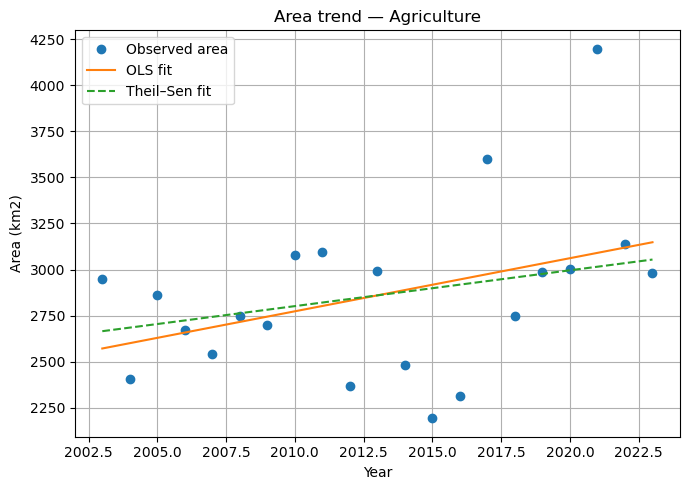

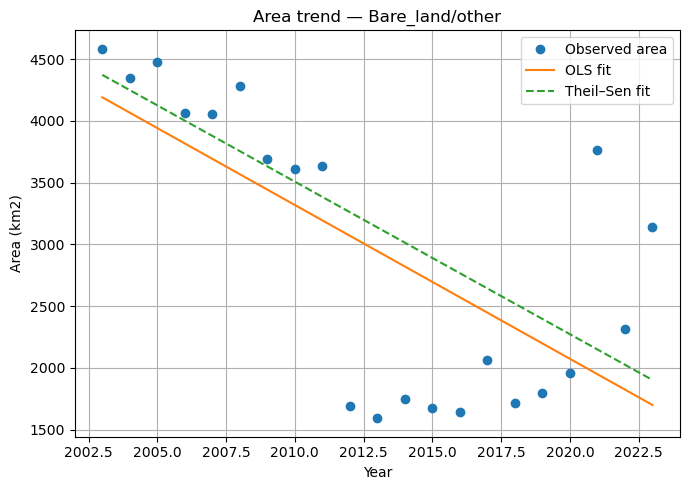

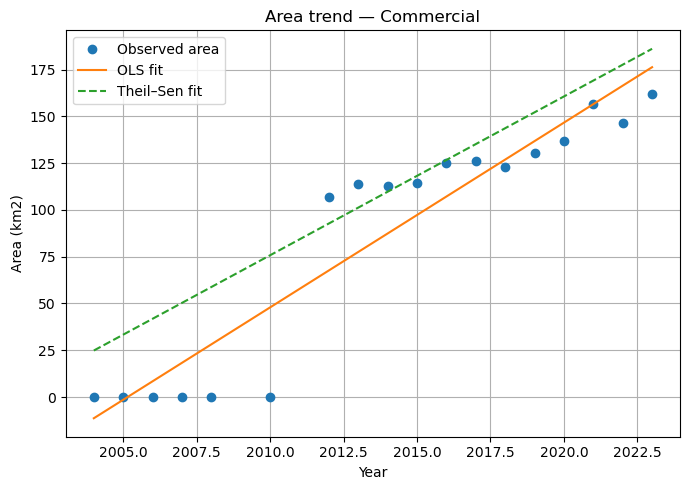

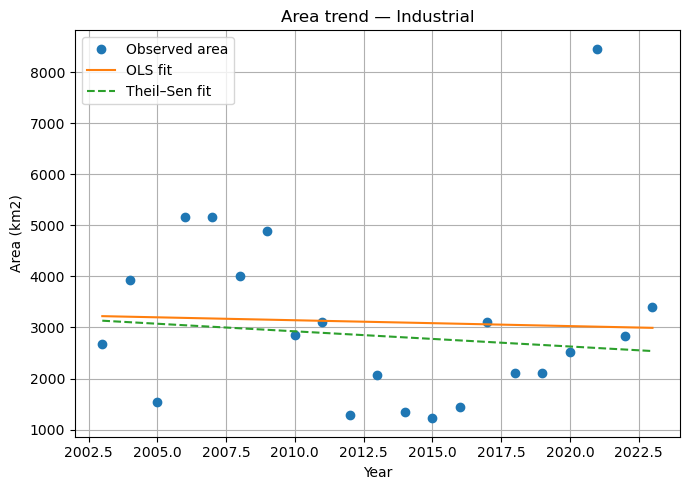

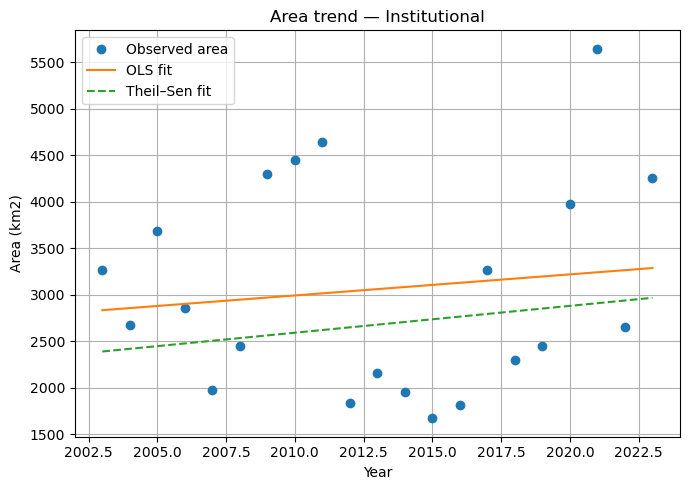

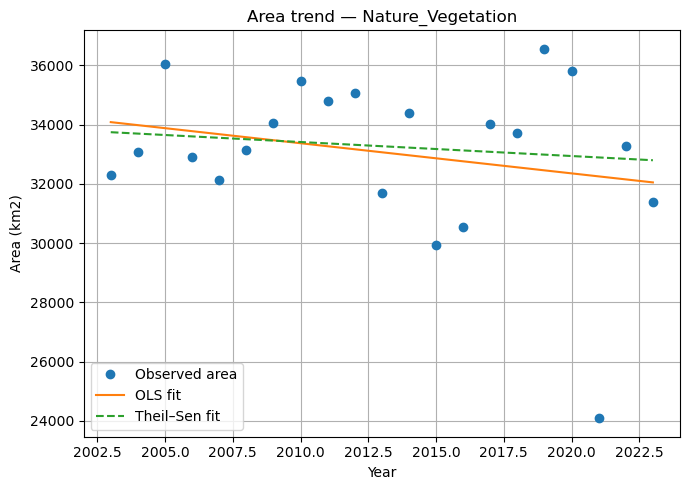

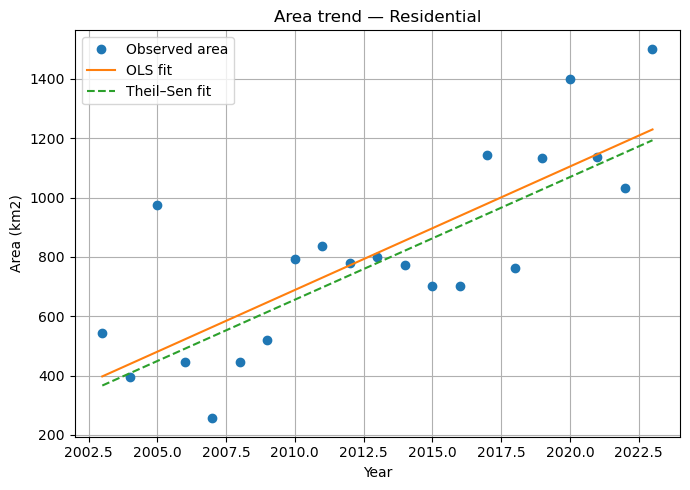

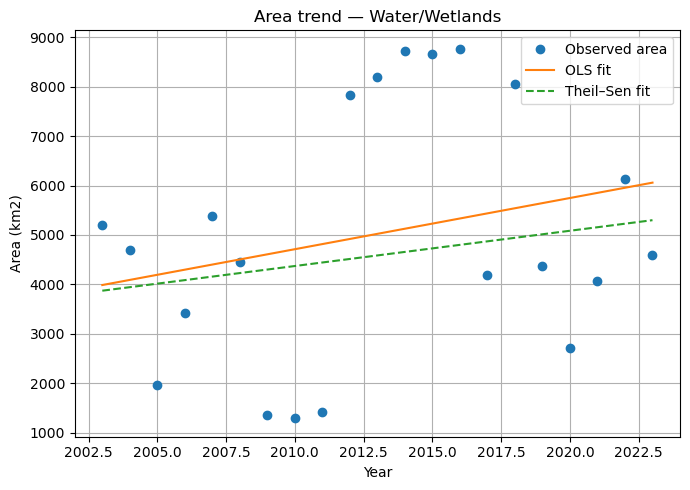

✅ Trend analysis complete.

--- Trend Summary ---
    ols_slope         ols_p    ts_slope         class_name
0   28.805261  7.716346e-02   19.423330        Agriculture
1 -124.553268  8.868446e-04 -123.518739    Bare_land/other
2    9.874442  9.722939e-09    8.487206         Commercial
3  -11.457236  8.607724e-01  -29.717819         Industrial
4   22.684123  5.887397e-01   28.900625      Institutional
5 -101.680862  3.120098e-01  -47.283879  Nature_Vegetation
6   41.614042  2.300762e-05   41.336701        Residential
7  103.540796  2.701077e-01   71.314714     Water/Wetlands
Agriculture: [2017]
Bare_land/other: [2012]
Commercial: [2008]
Industrial: [2012]
Institutional: [2017]
Nature_Vegetation: [2012]
Residential: [2017]
Water/Wetlands: [2012]
          class_name break_years
0        Agriculture      [2017]
1    Bare_land/other      [2012]
2         Commercial      [2008]
3         Industrial      [2012]
4      Institutional      [2017]
5  Nature_Vegetation      [2012]
6        Reside

In [35]:

# ---------------------------
# Step 6: Time Series Modeling
# ---------------------------
# 6.1. Trend analysis
SB_areas_wide, SB_trend_df = analyze_area_trends(SB_df_area, value_col='area_km2', plot=True)

print("\n--- Trend Summary ---")
print(SB_trend_df)

# 6.2. Break detection
SB_breaks_df = detect_breaks_all(SB_areas_wide, model="l2", n_bkps=1, verbose=True)
print(SB_breaks_df)



---

## 3. Orange County

**Training asset:** `projects/ee-mcvalenciac/assets/OR_osm_lulc_training_clean2`  
**Time range:** 2003–2023 | **Training target year:** 2023  
**RF trees:** 400 | **Samples per class:** 600

> **Note:** Orange County has a compact bounding box. The alternative bbox
> `[-117.94, 33.38, -117.41, 33.92]` may be needed if the standard one returns
> features from adjacent counties.


### 3.1 Steps 1–4

In [24]:
# ---------------------------
# Step 1-3: Define study area and extract time series from Landasat collection 
# ---------------------------

# Time of analysis
start_year=2003
end_year=2023
training_target = 2023

# Call functions
OR_roi, OR_landsat_by_year, OR_composite_by_year = run_landsat_pipeline(
    county_name='Orange',
    state_fips='06',
    start_year=start_year,
    end_year=end_year,
    use_glcm=True
)

# ---------------------------
# Step 4: Create Land Use Class or Index Trends
# ---------------------------
location = "Orange County, California, USA"

# OSM polygons 
OR_gdf_raw_2023 = get_osm_landuse(location, download_year=2023)

# Reclassify and save to export
OR_cleaned_gdf_2023 = clean_and_reclassify_osm_landuse(OR_gdf_raw_2023, simplify_tolerance=10) # Reclassify

# Get roads
OR_roads_gdf_2023 = get_osm_roads(location, buffer_m=5)

# merge data
OR_merged_training_2023 = merge_osm_training_layers(OR_cleaned_gdf_2023, 
                                        OR_roads_gdf_2023, 
                                        output_path=path+"Shapefiles/OR_osm_lulc_training.shp")


# Inspect
print(OR_merged_training_2023['landuse_group'].value_counts())

Landsat by year: 
Year 2003: 42 images
Landsat by year: 
Year 2004: 54 images
Landsat by year: 
Year 2005: 60 images
Landsat by year: 
Year 2006: 59 images
Landsat by year: 
Year 2007: 58 images
Landsat by year: 
Year 2008: 53 images
Landsat by year: 
Year 2009: 56 images
Landsat by year: 
Year 2010: 64 images
Landsat by year: 
Year 2011: 58 images
Landsat by year: 
Year 2012: 32 images
Landsat by year: 
Year 2013: 28 images
Landsat by year: 
Year 2014: 34 images
Landsat by year: 
Year 2015: 28 images
Landsat by year: 
Year 2016: 25 images
Landsat by year: 
Year 2017: 27 images
Landsat by year: 
Year 2018: 32 images
Landsat by year: 
Year 2019: 25 images
Landsat by year: 
Year 2020: 34 images
Landsat by year: 
Year 2021: 28 images
Landsat by year: 
Year 2022: 18 images
Landsat by year: 
Year 2023: 10 images
Composite for 2003 ready.
Composite for 2004 ready.
Composite for 2005 ready.
Composite for 2006 ready.
Composite for 2007 ready.
Composite for 2008 ready.
Composite for 2009 ready.

c:\Users\mariacvc\AppData\Local\miniconda3\envs\geo\Lib\site-packages\geopandas\geoseries.py:906: UserWarning: GeoSeries.notna() previously returned False for both missing (None) and empty geometries. Now, it only returns False for missing values. Since the calling GeoSeries contains empty geometries, the result has changed compared to previous versions of GeoPandas.
Given a GeoSeries 's', you can use '~s.is_empty & s.notna()' to get back the old behaviour.

To further ignore this warning, you can do: 
import warnings; warnings.filterwarnings('ignore', 'GeoSeries.notna', UserWarning)
  return self.notna()


  → After 90 m erosion: 2094 polygons remain

✅ Cleaned and reclassified OSM polygons
Total features: 2094
Land use classes:
 landuse_group
Residential          1537
Commercial            283
Industrial            109
Water/Wetlands         43
Agriculture            40
Bare_land/other        34
Nature_Vegetation      25
Institutional          23
Name: count, dtype: int64
✅ Downloaded and buffered 174162 cleaned road polygons for Orange County, California, USA


C:\Users\mariacvc\AppData\Local\Temp\ipykernel_36828\3551610132.py:23: UserWarning: Geometry is in a geographic CRS. Results from 'area' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

  merged["area_m2"] = merged.geometry.area


Start counts:
 landuse_group
Transport            174162
Residential            1667
Commercial              303
Industrial              112
Water/Wetlands           62
Agriculture              46
Bare_land/other          40
Nature_Vegetation        38
Institutional            26
Name: count, dtype: int64 

End counts:
 landuse_group
Transport            174092
Residential           10115
Commercial              890
Industrial              243
Bare_land/other          99
Water/Wetlands           61
Agriculture              50
Institutional            50
Nature_Vegetation        46
Name: count, dtype: int64 



c:\Users\mariacvc\AppData\Local\miniconda3\envs\geo\Lib\site-packages\geopandas\geodataframe.py:1968: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  super().__setitem__(key, value)
C:\Users\mariacvc\AppData\Local\Temp\ipykernel_36828\3551610132.py:39: UserWarning: Column names longer than 10 characters will be truncated when saved to ESRI Shapefile.
  gdf.to_file(output_path)
c:\Users\mariacvc\AppData\Local\miniconda3\envs\geo\Lib\site-packages\pyogrio\raw.py:723: RuntimeWarning: Normalized/laundered field name: 'landuse_code' to 'landuse_co'
  ogr_write(
c:\Users\mariacvc\AppData\Local\miniconda3\envs\geo\Lib\site-packages\pyogrio\raw.py:723: RuntimeWarning: Normalized/laundered field name: 'landuse_group' to 'landuse_gr'
  ogr_write(


📁 Saved merged training dataset: C:/Users/mariacvc/Box/Catalina Valencia/Project 4 - 2025NCST-Caltrans/Task2_LU_Analysis/Python/Shapefiles/OR_osm_lulc_training.shp
✅ Final merged training polygons: 185646
landuse_group
Transport            174092
Residential           10115
Commercial              890
Industrial              243
Bare_land/other          99
Water/Wetlands           61
Agriculture              50
Institutional            50
Nature_Vegetation        46
Name: count, dtype: int64
landuse_group
Transport            174092
Residential           10115
Commercial              890
Industrial              243
Bare_land/other          99
Water/Wetlands           61
Agriculture              50
Institutional            50
Nature_Vegetation        46
Name: count, dtype: int64


### 3.2 Step 5: Classification

In [26]:
OR_out_RF = run_supervised_classification(
    roi=OR_roi,
    composite_by_year=OR_composite_by_year,
    training_asset="projects/ee-mcvalenciac/assets/OR_osm_lulc_training",
    target_year=training_target,
    samples_per_class=600,
    rf_trees=400
)
# Breaking here to decide which model to use for area estimation and export to GEE for tile export

Samples: 
Train samples: 3485
Test samples: 2215
Random Forest Performance: 
Overall Accuracy: 0.725
Kappa: 0.611
Producers Accuracy: [[0.8206896551724138], [0.5048780487804878], [0.8545797922568461], [0], [0.9090909090909091], [0.6650485436893204], [0.125], [1]]
Users Accuracy: [[0.7933333333333333, 0.5864022662889519, 0.8379629629629629, 0, 0.6748466257668712, 0.8838709677419355, 0.15151515151515152, 0.02857142857142857]]
[[238, 13, 15, 6, 3, 2, 5, 8], [40, 207, 151, 1, 0, 1, 0, 10], [8, 131, 905, 0, 0, 2, 5, 8], [0, 0, 0, 0, 41, 12, 0, 33], [0, 0, 0, 2, 110, 1, 0, 8], [12, 0, 3, 0, 2, 137, 18, 34], [2, 2, 6, 17, 7, 0, 5, 1], [0, 0, 0, 0, 0, 0, 0, 3]]


In [31]:
# 5.1. Classification
OR_results = OR_out_RF.copy()

# Visualize classfication map
OR_classified_img = OR_composite_by_year[2023].select(OR_results['bands']).classify(OR_results['classifier'])


# Add to map (if using geemap)
import geemap
Map = geemap.Map()
Map.centerObject(OR_roi, 10)
Map.addLayer(OR_classified_img, {'min':0, 'max':8, 'palette':['#fee8c8','#fdbb84','#e34a33','#addd8e','#31a354','#2b8cbe','#cccccc', "#0c0909"]}, 'LULC Classified 2023') #, "#5e5c5c"


# 5.2. Area estimation
code_map = {
    0: 'Residential',
    1: 'Commercial',
    2: 'Industrial',
    3: 'Agriculture',
    4: 'Nature_Vegetation',
    5: 'Water/Wetlands',
    6: 'Institutional',
    7: 'Bare_land/other'#,
    #8: 'Transport'
}


OR_df_area = estimate_area_by_class_tiled_export(
    classifier=OR_results['classifier'],
    composite_by_year=OR_composite_by_year,
    roi=OR_roi,
    predictor_bands=OR_results['bands'],
    code_map=code_map,
    start_year=start_year,
    end_year=end_year,
    cell_km=10,        # try 10; if SB heavy, try 20
    tileScale=16       # 16 or 32 is often needed for SB
)


# Braking here to save data from GEE

✅ Export started: tileAreas_2003_10km
✅ Export started: tileConf_2003_10km_thr60
✅ Export started: tileAreas_2004_10km
✅ Export started: tileConf_2004_10km_thr60
✅ Export started: tileAreas_2005_10km
✅ Export started: tileConf_2005_10km_thr60
✅ Export started: tileAreas_2006_10km
✅ Export started: tileConf_2006_10km_thr60
✅ Export started: tileAreas_2007_10km
✅ Export started: tileConf_2007_10km_thr60
✅ Export started: tileAreas_2008_10km
✅ Export started: tileConf_2008_10km_thr60
✅ Export started: tileAreas_2009_10km
✅ Export started: tileConf_2009_10km_thr60
✅ Export started: tileAreas_2010_10km
✅ Export started: tileConf_2010_10km_thr60
✅ Export started: tileAreas_2011_10km
✅ Export started: tileConf_2011_10km_thr60
✅ Export started: tileAreas_2012_10km
✅ Export started: tileConf_2012_10km_thr60
✅ Export started: tileAreas_2013_10km
✅ Export started: tileConf_2013_10km_thr60
✅ Export started: tileAreas_2014_10km
✅ Export started: tileConf_2014_10km_thr60
✅ Export started: tileAreas_

In [ ]:
# 5.3. Call data exported from GEE
# Convert tile tables → yearly area totals (pandas)
OR_df_area = aggregate_tile_csvs("GEE_exports", code_map, prefix="tileAreas")
OR_df_conf = aggregate_conf_csvs("GEE_exports", prefix="tileConf")


# Convert the DataFrame back to dicts for export
OR_results_list = OR_df_area.to_dict(orient='records')
OR_results_Conf = OR_df_conf.to_dict(orient='records')

# 5.4. Checks
# Yearly confidence diagnostics
OR_conf_summary = summarize_yearly_conf(OR_df_conf)
print(OR_conf_summary)

# Identify worst tiles
OR_problem_tiles = identify_problem_tiles(OR_df_conf)
print("Problem tiles:", len(OR_problem_tiles))

# Detect temporally unstable zones
OR_tile_instability = temporal_instability(OR_df_conf)

# Combine diagnostics into one “problem index”
OR_df_conf = build_problem_index(OR_df_conf)
OR_df_conf.sort_values("problem_index", ascending=False).head()

conf_year = (OR_df_conf
             .groupby("year", as_index=False)[["problem_index","lowconf_frac","mean_conf"]]
             .mean())

year_join = OR_df_area.merge(conf_year, on="year", how="left")


### 3.3 Step 6: Time Series Modeling

In [ ]:
# ---------------------------
# Step 6: Time Series Modeling
# ---------------------------
# 6.1. Trend analysis
OR_areas_wide, OR_trend_df = analyze_area_trends(OR_df_area, value_col='area_km2', plot=True)

print("\n--- Trend Summary ---")
print(OR_trend_df)

# 6.2. Break detection
OR_breaks_df = detect_breaks_all(OR_areas_wide, model="l2", n_bkps=1, verbose=True)
print(OR_breaks_df)



---

## 4. Riverside County

**Training asset:** `projects/ee-mcvalenciac/assets/Riverside_osm_lulc_training`  
**Time range:** 2003–2023 | **Training target year:** 2023  
**RF trees:** 400 | **Samples per class:** 500

> **Note:** Riverside uses a longer time range (2003–2023) to capture the full
> Inland Empire logistics expansion cycle. GLCM textures are disabled (`use_glcm=False`)
> to reduce compute load for this larger temporal window.


### 4.1 Steps 1–4

In [25]:
# ---------------------------
# Step 1-3: Define study area and extract time series from Landasat collection 
# ---------------------------

# Time of analysis
start_year=2003
end_year=2023
training_target = 2023

# Call functions
ri_roi, ri_landsat_by_year, ri_composite_by_year = run_landsat_pipeline(
    county_name='Riverside',
    state_fips='06',
    start_year=start_year,
    end_year=end_year
)

# ---------------------------
# Step 4: Create Land Use Class or Index Trends
# ---------------------------
location = "Riverside County, California, USA"
# OSM polygons 
ri_gdf_raw = get_osm_landuse(location, download_year=2023)

# Reclassify and save to export
ri_cleaned_gdf = clean_and_reclassify_osm_landuse(
    ri_gdf_raw,
    simplify_tolerance=10
    )

# Get roads
ri_roads_gdf = get_osm_roads(location, buffer_m=5)

# merge data
ri_merged_training = merge_osm_training_layers(ri_cleaned_gdf, 
                                        ri_roads_gdf, 
                                        output_path=path+"Shapefiles/RI_osm_lulc_training.shp")

# Inspect
print(ri_merged_training['landuse_group'].value_counts())


Landsat by year: 
Year 2003: 96 images
Landsat by year: 
Year 2004: 125 images
Landsat by year: 
Year 2005: 134 images
Landsat by year: 
Year 2006: 130 images
Landsat by year: 
Year 2007: 129 images
Landsat by year: 
Year 2008: 123 images
Landsat by year: 
Year 2009: 119 images
Landsat by year: 
Year 2010: 132 images
Landsat by year: 
Year 2011: 131 images
Landsat by year: 
Year 2012: 67 images
Landsat by year: 
Year 2013: 61 images
Landsat by year: 
Year 2014: 70 images
Landsat by year: 
Year 2015: 64 images
Landsat by year: 
Year 2016: 55 images
Landsat by year: 
Year 2017: 62 images
Landsat by year: 
Year 2018: 65 images
Landsat by year: 
Year 2019: 63 images
Landsat by year: 
Year 2020: 72 images
Landsat by year: 
Year 2021: 59 images
Landsat by year: 
Year 2022: 39 images
Landsat by year: 
Year 2023: 28 images
Composite for 2003 ready.
Composite for 2004 ready.
Composite for 2005 ready.
Composite for 2006 ready.
Composite for 2007 ready.
Composite for 2008 ready.
Composite for 200

c:\Users\mariacvc\AppData\Local\miniconda3\envs\geo\Lib\site-packages\geopandas\geoseries.py:906: UserWarning: GeoSeries.notna() previously returned False for both missing (None) and empty geometries. Now, it only returns False for missing values. Since the calling GeoSeries contains empty geometries, the result has changed compared to previous versions of GeoPandas.
Given a GeoSeries 's', you can use '~s.is_empty & s.notna()' to get back the old behaviour.

To further ignore this warning, you can do: 
import warnings; warnings.filterwarnings('ignore', 'GeoSeries.notna', UserWarning)
  return self.notna()


  → After 90 m erosion: 2704 polygons remain

✅ Cleaned and reclassified OSM polygons
Total features: 2704
Land use classes:
 landuse_group
Residential          1170
Agriculture           740
Nature_Vegetation     233
Commercial            195
Industrial            165
Bare_land/other       101
Water/Wetlands         65
Institutional          33
Transport               2
Name: count, dtype: int64
✅ Downloaded and buffered 193339 cleaned road polygons for Riverside County, California, USA


C:\Users\mariacvc\AppData\Local\Temp\ipykernel_36828\3551610132.py:23: UserWarning: Geometry is in a geographic CRS. Results from 'area' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

  merged["area_m2"] = merged.geometry.area


Start counts:
 landuse_group
Transport            193341
Residential            1315
Agriculture             769
Nature_Vegetation       295
Commercial              198
Industrial              182
Water/Wetlands          135
Bare_land/other         107
Institutional            38
Name: count, dtype: int64 

End counts:
 landuse_group
Transport            193339
Residential            6541
Agriculture             859
Commercial              355
Nature_Vegetation       309
Industrial              282
Bare_land/other         267
Water/Wetlands          125
Institutional            68
Name: count, dtype: int64 



c:\Users\mariacvc\AppData\Local\miniconda3\envs\geo\Lib\site-packages\geopandas\geodataframe.py:1968: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  super().__setitem__(key, value)
C:\Users\mariacvc\AppData\Local\Temp\ipykernel_36828\3551610132.py:39: UserWarning: Column names longer than 10 characters will be truncated when saved to ESRI Shapefile.
  gdf.to_file(output_path)
c:\Users\mariacvc\AppData\Local\miniconda3\envs\geo\Lib\site-packages\pyogrio\raw.py:723: RuntimeWarning: Normalized/laundered field name: 'landuse_code' to 'landuse_co'
  ogr_write(
c:\Users\mariacvc\AppData\Local\miniconda3\envs\geo\Lib\site-packages\pyogrio\raw.py:723: RuntimeWarning: Normalized/laundered field name: 'landuse_group' to 'landuse_gr'
  ogr_write(


📁 Saved merged training dataset: C:/Users/mariacvc/Box/Catalina Valencia/Project 4 - 2025NCST-Caltrans/Task2_LU_Analysis/Python/Shapefiles/RI_osm_lulc_training.shp
✅ Final merged training polygons: 202145
landuse_group
Transport            193339
Residential            6541
Agriculture             859
Commercial              355
Nature_Vegetation       309
Industrial              282
Bare_land/other         267
Water/Wetlands          125
Institutional            68
Name: count, dtype: int64
landuse_group
Transport            193339
Residential            6541
Agriculture             859
Commercial              355
Nature_Vegetation       309
Industrial              282
Bare_land/other         267
Water/Wetlands          125
Institutional            68
Name: count, dtype: int64


### 4.2 Step 5: Classification

In [34]:
# Test multiple models and parameters


RI_out_RF = run_supervised_classification(
    roi=ri_roi,
    composite_by_year=ri_composite_by_year,
    training_asset="projects/ee-mcvalenciac/assets/RI_osm_lulc_training",
    target_year=training_target,
    samples_per_class=500,
    rf_trees=400
)


Samples: 
Train samples: 3738
Test samples: 1262
Random Forest Performance: 
Overall Accuracy: 0.660
Kappa: 0.584
Producers Accuracy: [[0.6214285714285714], [0.5943396226415094], [0.21428571428571427], [0.36666666666666664], [0.7909738717339667], [1], [0.8025751072961373], [0.4114285714285714]]
Users Accuracy: [[0.6541353383458647, 0.9130434782608695, 0.13125, 0.171875, 0.8062953995157385, 0.686046511627907, 0.958974358974359, 0.5070422535211268]]
[[87, 1, 6, 10, 16, 2, 0, 18], [6, 63, 32, 0, 1, 0, 0, 4], [17, 5, 21, 2, 43, 3, 0, 7], [1, 0, 2, 11, 8, 6, 0, 2], [11, 0, 1, 38, 333, 16, 0, 22], [0, 0, 0, 0, 0, 59, 0, 0], [0, 0, 26, 3, 0, 0, 187, 17], [11, 0, 72, 0, 12, 0, 8, 72]]


In [ ]:
# ---------------------------
# Step 5: Classification
# ---------------------------
# 5.1. Classification
ri_results = RI_out_RF.copy()

# Visualize classfication map
ri_classified_img = ri_composite_by_year[2023].select(ri_results['bands']).classify(ri_results['classifier'])

# Add to map (if using geemap)
import geemap
Map = geemap.Map()
Map.centerObject(ri_roi, 10)
Map.addLayer(ri_classified_img, {'min':0, 'max':8, 'palette':['#fee8c8','#fdbb84','#e34a33','#addd8e','#31a354','#2b8cbe','#cccccc', "#0c0909", "#5e5c5c"]}, 'LULC Classified 2023')


# 5.2. Area estimation
code_map = {
    0: 'Residential',
    1: 'Commercial',
    2: 'Industrial',
    3: 'Agriculture',
    4: 'Nature_Vegetation',
    5: 'Water/Wetlands',
    6: 'Institutional',
    7: 'Bare_land/other',
    8: 'Transport'
}

ri_df_area = estimate_area_by_class_tiled_export(
    classifier=ri_results['classifier'],
    composite_by_year=ri_composite_by_year,
    roi=ri_roi,
    predictor_bands=ri_results['bands'],
    code_map=code_map,
    start_year=2003,
    end_year=2023,
    cell_km=10,        # try 10; if SB heavy, try 20
    tileScale=16       # 16 or 32 is often needed for SB
)


# Braking here to save data from GEE



### 4.3 Step 6: Time Series Modeling

In [ ]:
# Call data exported from GEE
# Convert tile tables → yearly area totals (pandas)
# Convert tile tables → yearly area totals (pandas)
ri_df_area = aggregate_tile_csvs("GEE_exports", code_map, prefix="tileAreas")

ri_df_area.head(10)

# Convert the DataFrame back to dicts for export
ri_results_list = ri_df_area.to_dict(orient='records')

# 5.3. Store
export_area_results_to_drive(ri_results_list, description='Riverside_LULC_Area_2000_2023')

# ---------------------------
# Step 6: Time Series Modeling
# ---------------------------
# Trend analysis
ri_areas_wide, ri_trend_df = analyze_area_trends(ri_df_area, value_col='area_km2', plot=True)
print("\n--- Trend Summary ---")
print(ri_trend_df)

# Break detection
ri_breaks_df = detect_breaks_all(ri_areas_wide, model="l2", n_bkps=1, verbose=True)
print(ri_breaks_df)

# Clustering

---

## 5. Ventura County

**Training asset:** `projects/ee-mcvalenciac/assets/VE_osm_lulc_training_clean2`  
**Time range:** 2012–2023 | **Training target year:** 2023  
**RF trees:** 400 | **Samples per class:** 500




### 5.1 Steps 1–4

In [27]:
# ---------------------------
# Step 1-3: Define study area and extract time series from Landasat collection 
# ---------------------------

# Time of analysis
start_year=2012
end_year=2023
training_target = 2023

# Call functions
VE_roi, VE_landsat_by_year, VE_composite_by_year = run_landsat_pipeline(
    county_name='Ventura',
    state_fips='06',
    start_year=start_year,
    end_year=end_year,
    use_glcm=True
)

# ---------------------------
# Step 4: Create Land Use Class or Index Trends
# ---------------------------
location = "Ventura County, California, USA"

# OSM polygons 
VE_gdf_raw_2023 = get_osm_landuse(location, download_year=2023)

# Reclassify and save to export
VE_cleaned_gdf_2023 = clean_and_reclassify_osm_landuse(VE_gdf_raw_2023, simplify_tolerance=10) # Reclassify

# Get roads
VE_roads_gdf_2023 = get_osm_roads(location, buffer_m=5)

# merge data
VE_merged_training_2023 = merge_osm_training_layers(VE_cleaned_gdf_2023, 
                                        VE_roads_gdf_2023, 
                                        output_path=path+"Shapefiles/VE_osm_lulc_training.shp")


# Inspect
print(VE_merged_training_2023['landuse_group'].value_counts())

Landsat by year: 
Year 2012: 27 images
Landsat by year: 
Year 2013: 24 images
Landsat by year: 
Year 2014: 22 images
Landsat by year: 
Year 2015: 23 images
Landsat by year: 
Year 2016: 21 images
Landsat by year: 
Year 2017: 20 images
Landsat by year: 
Year 2018: 27 images
Landsat by year: 
Year 2019: 20 images
Landsat by year: 
Year 2020: 28 images
Landsat by year: 
Year 2021: 20 images
Landsat by year: 
Year 2022: 15 images
Landsat by year: 
Year 2023: 5 images
Composite for 2012 ready.
Composite for 2013 ready.
Composite for 2014 ready.
Composite for 2015 ready.
Composite for 2016 ready.
Composite for 2017 ready.
Composite for 2018 ready.
Composite for 2019 ready.
Composite for 2020 ready.
Composite for 2021 ready.
Composite for 2022 ready.
Composite for 2023 ready.
✅ Downloaded 5773 land-use features from OSM for Ventura County, California, USA
Unique landuse types: {'grass': 2055, 'residential': 806, 'orchard': 718, 'construction': 356, 'farmland': 327, 'commercial': 177, 'retail':

c:\Users\mariacvc\AppData\Local\miniconda3\envs\geo\Lib\site-packages\geopandas\geoseries.py:906: UserWarning: GeoSeries.notna() previously returned False for both missing (None) and empty geometries. Now, it only returns False for missing values. Since the calling GeoSeries contains empty geometries, the result has changed compared to previous versions of GeoPandas.
Given a GeoSeries 's', you can use '~s.is_empty & s.notna()' to get back the old behaviour.

To further ignore this warning, you can do: 
import warnings; warnings.filterwarnings('ignore', 'GeoSeries.notna', UserWarning)
  return self.notna()


  → After 90 m erosion: 849 polygons remain

✅ Cleaned and reclassified OSM polygons
Total features: 849
Land use classes:
 landuse_group
Agriculture          428
Residential          256
Commercial            53
Industrial            35
Water/Wetlands        33
Bare_land/other       18
Institutional         13
Nature_Vegetation     13
Name: count, dtype: int64
✅ Downloaded and buffered 56533 cleaned road polygons for Ventura County, California, USA


C:\Users\mariacvc\AppData\Local\Temp\ipykernel_36828\3551610132.py:23: UserWarning: Geometry is in a geographic CRS. Results from 'area' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

  merged["area_m2"] = merged.geometry.area


Start counts:
 landuse_group
Transport            56533
Agriculture            549
Residential            290
Water/Wetlands          86
Commercial              58
Industrial              37
Bare_land/other         20
Nature_Vegetation       18
Institutional           13
Name: count, dtype: int64 

End counts:
 landuse_group
Transport            56484
Residential           2389
Agriculture            753
Commercial              89
Industrial              82
Water/Wetlands          76
Bare_land/other         23
Nature_Vegetation       18
Institutional           14
Name: count, dtype: int64 



c:\Users\mariacvc\AppData\Local\miniconda3\envs\geo\Lib\site-packages\geopandas\geodataframe.py:1968: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  super().__setitem__(key, value)
C:\Users\mariacvc\AppData\Local\Temp\ipykernel_36828\3551610132.py:39: UserWarning: Column names longer than 10 characters will be truncated when saved to ESRI Shapefile.
  gdf.to_file(output_path)
c:\Users\mariacvc\AppData\Local\miniconda3\envs\geo\Lib\site-packages\pyogrio\raw.py:723: RuntimeWarning: Normalized/laundered field name: 'landuse_code' to 'landuse_co'
  ogr_write(
c:\Users\mariacvc\AppData\Local\miniconda3\envs\geo\Lib\site-packages\pyogrio\raw.py:723: RuntimeWarning: Normalized/laundered field name: 'landuse_group' to 'landuse_gr'
  ogr_write(


📁 Saved merged training dataset: C:/Users/mariacvc/Box/Catalina Valencia/Project 4 - 2025NCST-Caltrans/Task2_LU_Analysis/Python/Shapefiles/VE_osm_lulc_training.shp
✅ Final merged training polygons: 59928
landuse_group
Transport            56484
Residential           2389
Agriculture            753
Commercial              89
Industrial              82
Water/Wetlands          76
Bare_land/other         23
Nature_Vegetation       18
Institutional           14
Name: count, dtype: int64
landuse_group
Transport            56484
Residential           2389
Agriculture            753
Commercial              89
Industrial              82
Water/Wetlands          76
Bare_land/other         23
Nature_Vegetation       18
Institutional           14
Name: count, dtype: int64


### 5.2 Step 5: Classification

In [35]:
VE_out_RF = run_supervised_classification(
    roi=VE_roi,
    composite_by_year=VE_composite_by_year,
    training_asset="projects/ee-mcvalenciac/assets/VE_osm_lulc_training",
    target_year=training_target,
    samples_per_class=500,
    rf_trees=400
)
# Breaking here to decide which model to use for area estimation and export to GEE for tile export

Samples: 
Train samples: 3161
Test samples: 1839
Random Forest Performance: 
Overall Accuracy: 0.412
Kappa: 0.307
Producers Accuracy: [[0.8947368421052632], [0.27741935483870966], [0.3848531684698609], [0.6463414634146342], [0.065625], [0.9183673469387755], [0.38461538461538464], [0.4027777777777778]]
Users Accuracy: [[0.3324022346368715, 0.2792207792207792, 0.5914489311163895, 0.6334661354581673, 0.875, 0.5806451612903226, 0.03355704697986577, 0.1676300578034682]]
[[119, 0, 4, 1, 0, 0, 9, 0], [41, 86, 150, 0, 0, 4, 24, 5], [82, 222, 249, 0, 0, 9, 51, 34], [2, 0, 3, 159, 3, 20, 32, 27], [110, 0, 4, 79, 21, 7, 22, 77], [0, 0, 0, 6, 0, 90, 1, 1], [0, 0, 6, 0, 0, 2, 5, 0], [4, 0, 5, 6, 0, 23, 5, 29]]


In [ ]:
# 5.1. Classification
VE_results = VE_out_RF.copy()

# Visualize classfication map
VE_classified_img = VE_composite_by_year[2023].select(VE_results['bands']).classify(VE_results['classifier'])


# Add to map (if using geemap)
import geemap
Map = geemap.Map()
Map.centerObject(VE_roi, 10)
Map.addLayer(VE_classified_img, {'min':0, 'max':8, 'palette':['#fee8c8','#fdbb84','#e34a33','#addd8e','#31a354','#2b8cbe','#cccccc', "#0c0909"]}, 'LULC Classified 2023') #, "#5e5c5c"


# 5.2. Area estimation
code_map = {
    0: 'Residential',
    1: 'Commercial',
    2: 'Industrial',
    3: 'Agriculture',
    4: 'Nature_Vegetation',
    5: 'Water/Wetlands',
    6: 'Institutional',
    7: 'Bare_land/other'#,
    #8: 'Transport'
}


VE_df_area = estimate_area_by_class_tiled_export(
    classifier=VE_results['classifier'],
    composite_by_year=VE_composite_by_year,
    roi=VE_roi,
    predictor_bands=VE_results['bands'],
    code_map=code_map,
    start_year=start_year,
    end_year=end_year,
    cell_km=10,        # try 10; if SB heavy, try 20
    tileScale=16       # 16 or 32 is often needed for SB
)


# Braking here to save data from GEE

In [ ]:
# 5.3. Call data exported from GEE
# Convert tile tables → yearly area totals (pandas)
VE_df_area = aggregate_tile_csvs("GEE_exports", code_map, prefix="tileAreas")
VE_df_conf = aggregate_conf_csvs("GEE_exports", prefix="tileConf")


# Convert the DataFrame back to dicts for export
VE_results_list = VE_df_area.to_dict(orient='records')
VE_results_Conf = VE_df_conf.to_dict(orient='records')

# 5.4. Checks
# Yearly confidence diagnostics
VE_conf_summary = summarize_yearly_conf(VE_df_conf)
print(VE_conf_summary)

# Identify worst tiles
VE_problem_tiles = identify_problem_tiles(VE_df_conf)
print("Problem tiles:", len(VE_problem_tiles))

# Detect temporally unstable zones
VE_tile_instability = temporal_instability(VE_df_conf)

# Combine diagnostics into one “problem index”
VE_df_conf = build_problem_index(VE_df_conf)
VE_df_conf.sort_values("problem_index", ascending=False).head()

conf_year = (VE_df_conf
             .groupby("year", as_index=False)[["problem_index","lowconf_frac","mean_conf"]]
             .mean())

year_join = VE_df_area.merge(conf_year, on="year", how="left")



### 5.3 Step 6: Time Series Modeling

In [ ]:
# ---------------------------
# Step 6: Time Series Modeling
# ---------------------------
# 6.1. Trend analysis
VE_areas_wide, VE_trend_df = analyze_area_trends(VE_df_area, value_col='area_km2', plot=True)

print("\n--- Trend Summary ---")
print(VE_trend_df)

# 6.2. Break detection
VE_breaks_df = detect_breaks_all(VE_areas_wide, model="l2", n_bkps=1, verbose=True)
print(VE_breaks_df)

#### Using the modal-filtered classified image

Both `run_supervised_classification` and `run_supervised_classification_SVM_RF`
now return a `'classified_img'` key containing the **post-filter classified raster**
in addition to the usual accuracy metrics.

```python
results = run_supervised_classification(...)

# Raw classifier output (unfiltered)
raw_img = composite_by_year[2023].select(results['bands']).classify(results['classifier'])

# Modal-filtered output (recommended for area estimation and visualisation)
smooth_img = results['classified_img']

# Use smooth_img for area estimation
df_area = estimate_area_by_class(
    classifier=results['classifier'],
    ...
)
```

> **Note:** accuracy metrics (OA, Kappa, confusion matrix) are evaluated on
> per-pixel classifier output **before** the modal filter, which is the
> methodologically correct approach. The filter is applied only to the
> final mapped product.


---

## Cross-County Comparison

This section aggregates results across all counties for comparative analysis.

### Classifier performance summary

| County | OA | Kappa | Notes |
|--------|-----|-------|-------|
| Los Angeles | 0.69 | 0.55 | Strong industrial recall (0.95) |
| San Bernardino | 0.59 | 0.50 | Desert/mountain extent inflates vegetation accuracy |
| Orange | 0.73 | 0.61 | Low agrecultural and institutional accuracy |
| Riverside | 0.66 | 0.58 | Low industrial recall (0.21) |
| Ventura | 0.41 | 0.31 | Low nature accuracy |

### Next steps

- [ ] Add Imperial County training asset and results
- [ ] Add San Joaquin County training asset and results
- [ ] Harmonize all county area CSVs for cross-county time series panel
- [ ] Create stacked map visualization for 2003, 2013, 2023


### Known issues to resolve

| Issue | Cell | Status |
|-------|------|--------|
| VIIRS discontinuity 2011–2012 | 11 | ⚠️ Document in methods |

